# Python for Finance — Session 4 companion notebook — instructor solutions

**Planning and building a program**

## How to use this notebook

In Session 3 you received two large exercises. Today we rebuild them **one task at a time**, then you practise the same method on three new exercises.

```
COMPLEX TASK
    -> PLAN YOUR TASKS
    -> CODE ONE TASK AT A TIME
    -> CHECK EACH IMPORTANT RESULT
    -> COMBINE THE TASKS
```

A **meta-algorithm** is the list of steps you write *before* coding. Each step answers four questions:

- **Input** — what does this step start from?
- **Task** — what does it do?
- **Output** — which object does it create?
- **Check** — how do we know the output is correct? (skip it when no useful check exists)

**How to work today**

- **Part I** (with the instructor): run the cells in order. When you see **Before running the next cell**, answer the question first.
- **Part II** (your turn): three exercises of about 30 minutes each. Cells marked `None` print "Not attempted yet." until you fill them, so **Run All** always works.

Run the next cell first. It imports the libraries and checks that the `data` folder sits next to this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
PARCEL_PATH = DATA_DIR / "session3_parcel_reliability.csv"
PRICES_PATH = DATA_DIR / "session4_portfolio_prices.csv"

for path in [PARCEL_PATH, PRICES_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"{path.as_posix()} not found: open this notebook from the folder "
            "that contains the 'data' directory."
        )
print("NumPy", np.__version__, "| pandas", pd.__version__)
print("Data files found.")

NumPy 1.26.4 | pandas 3.0.3
Data files found.


## Part I — How to break a complex task into smaller tasks

### 1. Expense claims: start from the full question

This is Exercise A of Session 3, in its original compact form.

An organisation receives nine expense claims. Each position across the five lists describes one claim. The policy, **in this order**:

1. An amount that is zero or negative is rejected.
2. A category not present in `category_limits` is rejected.
3. A receipt is required when the amount is greater than EUR 25; without it, the claim is rejected.
4. Otherwise, the reimbursed amount is the smaller of the claim and the category limit.
5. A valid claim below or at the limit is `approved`; a valid claim reduced to the limit is `capped`; all others are `rejected`.

Required: a claim-level audit trail `claim_results` (in input order), `totals_by_employee`, `rejected_by_employee`, the employee with the largest total, the ordered list `review_ids` of capped or rejected claims, and checks of the result.

In Session 3 this was one large task. We now take it apart.

In [2]:
claim_ids = ["C101", "C102", "C103", "C104", "C105",
             "C106", "C107", "C108", "C109"]
employees = ["Amina", "Leo", "Amina", "Marta", "Leo",
             "Marta", "Amina", "Leo", "Marta"]
categories = ["train", "meal", "hotel", "taxi", "hotel",
              "meal", "meal", "train", "hotel"]
amounts = [145.0, 42.0, 260.0, 30.0, 180.0,
           -5.0, 18.0, 210.0, 130.0]
has_receipt = [True, True, True, True, False,
               True, False, True, True]

category_limits = {"train": 160.0, "meal": 35.0, "hotel": 200.0}

### 1.1 Read the question: what do we start from, what must we produce?

**What information do we start from?**
- Five lists. Position `i` in every list describes the same claim `i`.
- One dictionary: category → maximum reimbursement.

**What must we produce?**

| Output | Form | Level |
|---|---|---|
| `claim_results` | list of 9 dictionaries, input order | one per **claim** |
| `totals_by_employee`, `rejected_by_employee` | dictionaries keyed by name | one per **employee** |
| employee with the largest total | a name and a number | one answer |
| `review_ids` | list of IDs, input order | one answer |

The outputs live at two levels: claims and employees. So the program needs at least two stages: first decide the claims, then summarise them by employee.

### 1.2 Plan the tasks (meta-algorithm)

These are the notes an experienced programmer would write before coding.

**Step 1 — Verify the inputs**\
Input: the five lists.\
Task: make sure position `i` refers to the same claim in every list.\
Output: nothing new; we now know the lists can be used together.\
Check: equal lengths; claim IDs unique.

**Step 2 — Decide one claim**\
Input: one category, one amount, one receipt flag, and the limits.\
Task: apply the five rules in order.\
Output: a status and a reimbursed amount.

**Step 3 — Test the decision**\
Input: the Step-2 function and a few claims whose answer we know by hand.\
Task: run the function on them before any loop.\
Check: the results equal our hand answers.

**Step 4 — Repeat for all claims**\
Input: the five lists and the Step-2 function.\
Task: decide every claim in order and keep one record per claim.\
Output: `claim_results`, a list of 9 dictionaries.\
Check: 9 records, same order as `claim_ids`, four keys each.

**Step 5 — Summarise by employee**\
Input: `claim_results`.\
Task: add up reimbursements and count rejections per employee.\
Output: `totals_by_employee`, `rejected_by_employee`.\
Check: the employee totals add up to the claim-level total.

**Step 6 — Answer the questions**\
Input: the summaries and the records.\
Task: find the largest total; list the IDs to review.\
Output: `top_employee`, `top_total`, `review_ids`.\
Check: `review_ids` follows the input order.

**Step 7 — Reconcile**\
Input: all the objects above.\
Task: compare them with the expected Session-3 results.\
Check: every assertion passes.

**Which Python tool can do each task?** Every tool below was taught in Session 1.

| Step | Task | Python tool | Why this tool |
|---|---|---|---|
| 1 | same length, unique IDs | `len()`, `set()`, `assert` | a set keeps each ID once; `assert` stops the program if a fact is false |
| 2 | one decision, rules in order | function with `if / elif / else` and `return` | the first true condition wins, exactly like "rules in order"; `return` gives a value later steps can store |
| 4 | walk through aligned lists | `zip()` + `for` | `zip` gives the `i`-th element of every list together |
| 4 | one record with named fields, kept in order | dictionary, `.append()` to a list | the list keeps the order, the dictionary names the fields |
| 5 | total and count per employee | dictionary with the name as key, `for` loop | the key identifies the group, the value is updated |
| 6 | largest total | `for` loop over `.items()`, keeping the best so far | uses only Session-1 tools |
| 6 | ordered subset of IDs | list comprehension with `if` | keeps the order (a set would not) |
| 7 | reconcile | `assert`, `sum()` | compares two independent calculations |

### 1.3 Step 1 — Verify the inputs

Using `assert`, `len()` and `set()`, verify that the five lists have the same length and that the claim IDs are unique.

In [3]:
n_claims = len(claim_ids)

assert len(employees) == n_claims
assert len(categories) == n_claims
assert len(amounts) == n_claims
assert len(has_receipt) == n_claims
assert len(set(claim_ids)) == n_claims     # a set keeps each ID once

print("Inputs are aligned:", n_claims, "claims, all IDs unique.")

Inputs are aligned: 9 claims, all IDs unique.


We now know that position `i` describes one claim. The report needs a decision for every claim, so the next task is to decide **one** claim.

### 1.4 Step 2 — Decide one claim

Define `assess_claim(category, amount, receipt, limits)` using `if / elif / else`. It must **return** `(status, reimbursed)`, not print it: Steps 4–6 need values they can store and add up.

**Before running the next cell:** claim C106 is a meal of −5 EUR. If the cap rule came first, what would happen to it?

In [4]:
def assess_claim(category, amount, receipt, limits):
    """Return (status, reimbursed) for one claim, applying the rules in order."""
    if amount <= 0:
        return "rejected", 0.0
    elif category not in limits:              # checks the keys of the dictionary
        return "rejected", 0.0
    elif amount > 25 and not receipt:
        return "rejected", 0.0
    elif amount > limits[category]:
        return "capped", limits[category]
    else:
        return "approved", amount

The order of the `if / elif` lines **is** the policy: the first true condition wins and the others are not tested. C106 stops at the first line; it can never reach the cap line.

### 1.5 Step 3 — Test the one-claim function before the loop

Before processing all claims, run the function on C101 and C104 (positions 0 and 3). Work out the answer by hand first. Then, using `assert`, test the cases where a mistake is most likely: a negative amount, exactly EUR 25 without a receipt, an amount above the limit.

In [5]:
print("C101:", assess_claim(categories[0], amounts[0], has_receipt[0], category_limits))
print("C104:", assess_claim(categories[3], amounts[3], has_receipt[3], category_limits))

assert assess_claim("train", 145.0, True, category_limits) == ("approved", 145.0)   # C101
assert assess_claim("taxi", 30.0, True, category_limits) == ("rejected", 0.0)       # C104: unknown category
assert assess_claim("meal", -5.0, True, category_limits) == ("rejected", 0.0)       # C106: rule 1 first
assert assess_claim("meal", 25.0, False, category_limits) == ("approved", 25.0)     # 25 is not "greater than 25"
assert assess_claim("hotel", 260.0, True, category_limits) == ("capped", 200.0)     # C103
print("One-claim tests passed.")

C101: ('approved', 145.0)
C104: ('rejected', 0.0)
One-claim tests passed.


We can decide one claim and we trust the decision. The report needs the decision for **all nine** claims, stored in order. So the next task is to repeat Step 2 inside a loop and keep each result.

**Before running the next cell:** what object should the loop create, and what should one element of it look like?

### 1.6 Step 4 — Repeat for all claims and keep one record per claim

Using `zip()` and a `for` loop, process the aligned claim lists. For each claim, call `assess_claim`, create a dictionary with the keys `claim_id`, `employee`, `status`, `reimbursed`, and append it to `claim_results`.

In [6]:
claim_results = []

for claim_id, employee, category, amount, receipt in zip(
        claim_ids, employees, categories, amounts, has_receipt):
    status, reimbursed = assess_claim(category, amount, receipt, category_limits)
    claim_results.append({
        "claim_id": claim_id,
        "employee": employee,
        "status": status,
        "reimbursed": reimbursed,
    })

claim_results[:2]

[{'claim_id': 'C101',
  'employee': 'Amina',
  'status': 'approved',
  'reimbursed': 145.0},
 {'claim_id': 'C102',
  'employee': 'Leo',
  'status': 'capped',
  'reimbursed': 35.0}]

Check the loop's output before using it: one record per claim, the same order as the input, the four required keys.

In [7]:
assert len(claim_results) == n_claims
assert [result["claim_id"] for result in claim_results] == claim_ids   # same order

for result in claim_results:
    assert set(result) == {"claim_id", "employee", "status", "reimbursed"}
    print(result["claim_id"], result["employee"], result["status"], result["reimbursed"])

C101 Amina approved 145.0
C102 Leo capped 35.0
C103 Amina capped 200.0
C104 Marta rejected 0.0
C105 Leo rejected 0.0
C106 Marta rejected 0.0
C107 Amina approved 18.0
C108 Leo capped 160.0
C109 Marta approved 130.0


We have one record per claim. The next questions are about **employees**, not claims. So the next task moves from the claim level to the employee level: a summary keyed by employee name.

### 1.7 Step 5 — Summarise by employee

Using a dictionary and a `for` loop over `claim_results`, build `totals_by_employee` and `rejected_by_employee`. The first time a name appears, its key does not exist yet: create it with 0 before adding to it.

In [8]:
totals_by_employee = {}
rejected_by_employee = {}

for result in claim_results:
    name = result["employee"]
    if name not in totals_by_employee:          # first claim of this employee
        totals_by_employee[name] = 0.0
        rejected_by_employee[name] = 0
    totals_by_employee[name] += result["reimbursed"]
    if result["status"] == "rejected":
        rejected_by_employee[name] += 1

print(totals_by_employee)
print(rejected_by_employee)

{'Amina': 363.0, 'Leo': 195.0, 'Marta': 130.0}
{'Amina': 0, 'Leo': 1, 'Marta': 2}


**Check.** Compute the same total twice, once from the claims and once from the employees. If they differ, the error is in the cell above.

In [9]:
claim_level_total = sum([result["reimbursed"] for result in claim_results])
employee_level_total = sum(totals_by_employee.values())
n_rejected = len([result for result in claim_results if result["status"] == "rejected"])

assert claim_level_total == employee_level_total
assert sum(rejected_by_employee.values()) == n_rejected
print("claim-level total:", claim_level_total, "| employee-level total:", employee_level_total)

claim-level total: 688.0 | employee-level total: 688.0


Both management questions can now be answered from objects that already exist: no new pass over the raw lists is needed.

### 1.8 Step 6 — Answer the management questions

- Largest total: using a `for` loop over `totals_by_employee.items()`, keep the best employee seen so far.
- Claims to review: using a list comprehension with `if`, keep the IDs whose status is `capped` or `rejected`. A list keeps the input order; a set would not.

In [10]:
top_employee = None
top_total = -1.0                         # every total is >= 0, so the first employee replaces this
for name, total in totals_by_employee.items():
    if total > top_total:
        top_employee = name
        top_total = total
print("largest total:", top_employee, top_total)

review_ids = [result["claim_id"] for result in claim_results
              if result["status"] in ("capped", "rejected")]
print("claims to review:", review_ids)

assert review_ids == [claim_id for claim_id in claim_ids if claim_id in review_ids]   # input order

largest total: Amina 363.0
claims to review: ['C102', 'C103', 'C104', 'C105', 'C106', 'C108']


### 1.9 Step 7 — Reconcile with the Session-3 expected results

These are the expected results distributed with the Session-3 exercise. Each assertion compares one of our objects with them.

In [11]:
EXPECTED_RESULTS = [
    ("C101", "Amina", "approved", 145.0), ("C102", "Leo", "capped", 35.0),
    ("C103", "Amina", "capped", 200.0), ("C104", "Marta", "rejected", 0.0),
    ("C105", "Leo", "rejected", 0.0), ("C106", "Marta", "rejected", 0.0),
    ("C107", "Amina", "approved", 18.0), ("C108", "Leo", "capped", 160.0),
    ("C109", "Marta", "approved", 130.0),
]
EXPECTED_TOTALS = {"Amina": 363.0, "Leo": 195.0, "Marta": 130.0}
EXPECTED_REJECTED = {"Amina": 0, "Leo": 1, "Marta": 2}
EXPECTED_REVIEW = ["C102", "C103", "C104", "C105", "C106", "C108"]

as_tuples = [(r["claim_id"], r["employee"], r["status"], r["reimbursed"]) for r in claim_results]
assert as_tuples == EXPECTED_RESULTS
assert totals_by_employee == EXPECTED_TOTALS
assert rejected_by_employee == EXPECTED_REJECTED
assert review_ids == EXPECTED_REVIEW
assert (top_employee, top_total) == ("Amina", 363.0)
assert claim_level_total == 688.0
print("All Session-3 results reproduced.")

All Session-3 results reproduced.


### 1.10 Another way to organise the same work

There is more than one good decomposition.

- **Route A — update as you go.** Decide one claim, store its record, and update the employee summaries immediately, inside the same loop.
- **Route B — build first, then summarise.** First build all records (Step 4), then summarise them (Step 5). This is what we did.

Route A below gives the same results in one pass.

In [12]:
claim_results_a = []
totals_a = {}
rejected_a = {}

for claim_id, employee, category, amount, receipt in zip(
        claim_ids, employees, categories, amounts, has_receipt):
    status, reimbursed = assess_claim(category, amount, receipt, category_limits)
    claim_results_a.append({"claim_id": claim_id, "employee": employee,
                            "status": status, "reimbursed": reimbursed})
    if employee not in totals_a:
        totals_a[employee] = 0.0
        rejected_a[employee] = 0
    totals_a[employee] += reimbursed
    if status == "rejected":
        rejected_a[employee] += 1

assert claim_results_a == claim_results
assert totals_a == totals_by_employee and rejected_a == rejected_by_employee
print("Route A and Route B agree.")

Route A and Route B agree.


| | Route A: update as you go | Route B: build first, then summarise |
|---|---|---|
| Passes over the data | one | two |
| Objects to inspect | fewer | the records are complete before any summary |
| When the result is wrong | the loop does three jobs, so the error can be in any of them | check Step 4 first, then Step 5 |

Neither route is "the" correct one. While you are learning, Route B is easier to check one step at a time.

### 1.11 From small tasks back to the full question

```
five lists ------------------ Step 1 --> verified inputs              (Session-3 task 1)
one claim ------------------- Step 2 --> assess_claim                 (task 2)
known claims ---------------- Step 3 --> tested function
five lists + assess_claim --- Step 4 --> claim_results (9 records)    (task 3)
claim_results --------------- Step 5 --> totals / rejected by employee (task 4)
summaries + records --------- Step 6 --> top_employee, review_ids     (task 5)
everything ------------------ Step 7 --> all checks pass              (task 6)
```

The large task was seven small tasks. Each produced one object, and each object was checked before the next task used it.

### 2. Parcel reliability: from a data question to a sequence of tasks

This is Exercise B of Session 3, in its original compact form.

An operations manager wants to compare delivery reliability across two regions. A row records the number of parcels and late parcels for one date, depot and service. Reliability is the fraction delivered on time:

`on-time rate = (recorded parcels - late parcels) / recorded parcels`

Rows without a recorded parcel total cannot contribute to this rate. Report regional performance by service, and show how express-service reliability evolved day by day for each region. The manager's reference level is 92%.

The depot-to-region lookup is given as a small table.

In [13]:
depots = pd.DataFrame({
    "depot_id": ["D01", "D02", "D03", "D04"],
    "region": ["North", "North", "South", "South"],
})
depots

,depot_id,region
0,D01,North
1,D02,North
2,D03,South
3,D04,South


### 2.1 Work backwards from the final answer

For a data question, it often helps to start from the **last** object and ask what must exist just before it.

1. The figure needs a table with **one row per date and one column per region**, containing express on-time rates.
2. A rate for a group (a date and a region, or a region and a service) needs **the sum of on-time parcels and the sum of recorded parcels** in that group.
3. Those sums need **every row** to have a numeric parcel count, an on-time count and a region.
4. A numeric parcel count needs the rows marked `not_recorded` to be handled.
5. A region on every row needs the `depots` table to be attached.

Read from 5 back to 1, this list gives the order of the tasks.

### 2.2 Plan the tasks (meta-algorithm)

**Step 1 — Load and inspect**\
Input: the CSV file. Task: load it and look at it before calculating.\
Output: `raw`. Check: 224 rows, 6 columns; find why `parcels` is not numeric.

**Step 2 — Repair the parcel counts**\
Input: `raw`. Task: convert `parcels` to numbers (the marker becomes missing), keep rows with a recorded count.\
Output: `repaired`, then `analysis`. Check: 224 − (number of markers) rows; no missing counts.

**Step 3 — Attach the region**\
Input: `analysis`, `depots`. Task: add the region of each depot.\
Output: `with_region`. Check: same number of rows; no missing region.

**Step 4 — On-time parcels**\
Input: `with_region`. Task: parcels minus late parcels, row by row.\
Output: a new column. Check: never negative, never above `parcels`.

**Step 5 — Counts per region and service**\
Input: `with_region`. Task: sum parcels, late parcels and on-time parcels, count rows, per region and service.\
Output: `summary` (4 rows). Check: the row counts add up to all rows of `with_region`.

**Step 6 — Rate per region and service**\
Input: `summary`. Task: divide the summed counts.\
Output: an `on_time_rate` column. Check: between 0 and 1.

**Step 7 — Daily express table**\
Input: `with_region`. Task: keep express rows; sum per date and region; divide; reshape to dates × regions.\
Output: `express`, `express_daily`, `daily_express`. Check: one long row per date and region.

**Step 8 — Check the daily table**\
Input: `daily_express`. Task: shape, missing and range checks; count days below 92%.\
Output: `days_below_92`. Check: 28 × 2, no missing, all rates in [0, 1].

**Step 9 — Figure**\
Input: `daily_express`. Task: one line per region and a 92% reference line.\
Output: `fig`, `ax`. Check: three lines drawn.

**Which Python tool can do each task?** Every tool below was taught in Session 2.

| Step | Task | Python tool | Why this tool |
|---|---|---|---|
| 1 | load and look | `pd.read_csv(..., parse_dates=["date"])`, `.shape`, `.dtypes`, `.head()` | see the table before trusting it |
| 2 | text → numbers, marker → missing | `pd.to_numeric(..., errors="coerce")`, `dropna(subset=...)` | "coerce" turns anything that is not a number into `NaN` |
| 3 | add information from a lookup table | `merge(..., how="left", validate="many_to_one")` | many rows share one depot; each depot has one region |
| 4 | new column from two columns | column arithmetic | works on the whole column, no loop |
| 5 | totals per group | `groupby([...]).agg(...)` | split into groups, sum inside each, combine |
| 6 | rate per group | division of two columns | divide **after** summing |
| 7 | keep some rows | `.loc[condition]` | a Boolean condition selects rows |
| 7 | long table → one row per date, one column per region | `pivot` / `pivot_table` | "From long to wide" |
| 8 | checks on a small table | `.shape`, `isna()`, `np.isfinite`, comparisons | |
| 9 | figure | `fig, ax = plt.subplots()`, `ax.plot`, `ax.axhline` | one Axes, one line per column |

### 2.3 Step 1 — Load and inspect

Using `pd.read_csv`, load the file. Parse the dates while loading with `parse_dates=["date"]`. Then look at the shape, the dtypes and the first rows.

In [14]:
raw = pd.read_csv(PARCEL_PATH, parse_dates=["date"])

print("rows, columns:", raw.shape)
print(raw.dtypes)
raw.head()

rows, columns: (224, 6)
date            datetime64[us]
depot_id                   str
service                    str
parcels                    str
late_parcels             int64
driver_hours           float64
dtype: object


,date,depot_id,service,parcels,late_parcels,driver_hours
0,2026-04-06,D01,standard,114,10,10.61
1,2026-04-06,D01,express,84,10,7.99
2,2026-04-06,D02,standard,126,7,11.90
3,2026-04-06,D02,express,96,0,9.28
4,2026-04-06,D03,standard,114,10,11.01


`parcels` is read as text, not as a number. Using `.loc[]` and `.str.isnumeric()`, show the rows whose `parcels` value is not made of digits.

In [15]:
not_digits = ~raw["parcels"].str.isnumeric()
print("rows that are not numbers:", not_digits.sum())
raw.loc[not_digits]

rows that are not numbers: 6


,date,depot_id,service,parcels,late_parcels,driver_hours
19,2026-04-08,D02,express,not_recorded,6,9.83
54,2026-04-12,D04,standard,not_recorded,5,11.01
88,2026-04-17,D01,standard,not_recorded,9,11.19
125,2026-04-21,D03,express,not_recorded,10,7.80
162,2026-04-26,D02,standard,not_recorded,5,10.72
199,2026-04-30,D04,express,not_recorded,6,10.20


We know the problem: some rows contain the word `not_recorded` instead of a count. A rate needs a numeric denominator, so the next task is to repair the column.

### 2.4 Step 2 — Repair the parcel counts and keep the usable rows

Using `pd.to_numeric(..., errors="coerce")`, convert `parcels` to numbers; the marker becomes `NaN`. Then, using `dropna(subset=["parcels"])`, keep only rows with a recorded count.

Why not replace the marker by 0? A row with 0 parcels and 6 late parcels is impossible, and it would change the rate.

In [16]:
repaired = raw.copy()
repaired["parcels"] = pd.to_numeric(repaired["parcels"], errors="coerce")
n_missing = repaired["parcels"].isna().sum()
print("missing parcel counts:", n_missing)

analysis = repaired.dropna(subset=["parcels"]).copy()
analysis["parcels"] = analysis["parcels"].astype(int)   # counts are whole numbers

assert len(analysis) == len(raw) - n_missing
assert analysis["parcels"].notna().all()
print("rows kept:", len(analysis))

missing parcel counts: 6
rows kept: 218


*Another way, from Session 2:* `pd.read_csv(..., na_values=["not_recorded"])` does Steps 1 and 2 while loading. Here we keep them separate so that we see the problem before repairing it.

Every row now has a numeric count, but no region. The manager asks about regions, so the next task is to attach the lookup table.

### 2.5 Step 3 — Attach the region

Using `merge` with the `depots` table, add a `region` column.
- `how="left"` keeps every delivery row.
- `validate="many_to_one"`: many delivery rows may share a depot, but one depot must have only one region. If not, pandas raises an error.

In [17]:
with_region = analysis.merge(depots, on="depot_id", how="left", validate="many_to_one")

assert len(with_region) == len(analysis)          # no row lost or duplicated
assert with_region["region"].notna().all()         # every depot found a region
print("rows:", len(with_region))
with_region.head(3)

rows: 218


,date,depot_id,service,parcels,late_parcels,driver_hours,region
0,2026-04-06,D01,standard,114,10,10.61,North
1,2026-04-06,D01,express,84,10,7.99,North
2,2026-04-06,D02,standard,126,7,11.90,North


### 2.6 Step 4 — On-time parcels

The rate needs on-time parcels. Add the column by subtracting two columns: no loop is needed.

In [18]:
with_region["on_time_parcels"] = with_region["parcels"] - with_region["late_parcels"]

assert (with_region["on_time_parcels"] >= 0).all()
assert (with_region["on_time_parcels"] <= with_region["parcels"]).all()
with_region.head(3)

,date,depot_id,service,parcels,late_parcels,driver_hours,region,on_time_parcels
0,2026-04-06,D01,standard,114,10,10.61,North,104
1,2026-04-06,D01,express,84,10,7.99,North,74
2,2026-04-06,D02,standard,126,7,11.90,North,119


Every row now has what a rate needs. The first question is about region/service groups.

**Before running the next cell:** should we compute a rate on every row and then average the rates, or add up the counts in each group first and divide once?

### 2.7 Step 5 — Counts per region and service

Using `groupby(["region", "service"])` with named aggregation, sum the recorded, late and on-time parcels and count the rows of each group.

In [19]:
summary = (with_region.groupby(["region", "service"])
                      .agg(recorded_parcels=("parcels", "sum"),
                           late_parcels=("late_parcels", "sum"),
                           on_time_parcels=("on_time_parcels", "sum"),
                           rows=("parcels", "size"))
                      .reset_index())

assert summary["rows"].sum() == len(with_region)
assert summary["recorded_parcels"].sum() == with_region["parcels"].sum()
summary

,region,service,recorded_parcels,late_parcels,on_time_parcels,rows
0,North,express,4785,289,4496,55
1,North,standard,6604,566,6038,54
2,South,express,4412,335,4077,54
3,South,standard,6454,646,5808,55


### 2.8 Step 6 — Rate per region and service: sum first, then divide

Why sum first? One row has 10 parcels, all on time (100%); another has 90 parcels, 72 on time (80%).

In [20]:
toy_parcels = np.array([10, 90])
toy_on_time = np.array([10, 72])

print("average of the two row rates:", (toy_on_time / toy_parcels).mean())
print("rate from the summed counts: ", toy_on_time.sum() / toy_parcels.sum())

average of the two row rates: 0.9
rate from the summed counts:  0.82


The average of row rates treats the 10-parcel row like the 90-parcel row. The rate of a group is its on-time parcels divided by its parcels, so we divide the **summed** columns.

In [21]:
summary["on_time_rate"] = summary["on_time_parcels"] / summary["recorded_parcels"]

assert summary["on_time_rate"].between(0, 1).all()
summary.sort_values("on_time_rate", ascending=False)

,region,service,recorded_parcels,late_parcels,on_time_parcels,rows,on_time_rate
0,North,express,4785,289,4496,55,0.939603
2,South,express,4412,335,4077,54,0.924071
1,North,standard,6604,566,6038,54,0.914294
3,South,standard,6454,646,5808,55,0.899907


North/express is the most reliable combination (about 94.0%), South/standard the least (about 90.0%).

The regional question is answered. The second question is about express service **day by day**: we need one rate per date and region, arranged as dates × regions.

**Before running the next cells:** this is four operations. Which ones, and in which order?

### 2.9 Step 7 — The daily express table

**7a.** Using `.loc[]`, keep the express rows.

In [22]:
express = with_region.loc[with_region["service"] == "express"]
print("express rows:", len(express))

express rows: 109


**7b.** Using `groupby(["date", "region"])`, sum the recorded and on-time parcels, then divide. Same idea as Step 6, with different groups.

In [23]:
express_daily = (express.groupby(["date", "region"])
                        .agg(recorded_parcels=("parcels", "sum"),
                             on_time_parcels=("on_time_parcels", "sum"))
                        .reset_index())
express_daily["on_time_rate"] = express_daily["on_time_parcels"] / express_daily["recorded_parcels"]

assert len(express_daily) == express["date"].nunique() * express["region"].nunique()
express_daily.head()

,date,region,recorded_parcels,on_time_parcels,on_time_rate
0,2026-04-06,North,180,170,0.944444
1,2026-04-06,South,162,152,0.938272
2,2026-04-07,North,176,165,0.937500
3,2026-04-07,South,158,143,0.905063
4,2026-04-08,North,81,75,0.925926


**7c.** The table is still long: one row per date **and** region. Using `pivot`, move the regions into the columns. Each date/region pair has exactly one rate, so `pivot` works (it raises an error if a pair appears twice, which is itself a check).

In [24]:
daily_express = express_daily.pivot(index="date", columns="region", values="on_time_rate")
daily_express.head()

region,North,South
date,,
2026-04-06,0.944444,0.938272
2026-04-07,0.937500,0.905063
2026-04-08,0.925926,0.929032
2026-04-09,0.935673,0.934911
2026-04-10,0.945652,0.904192


### 2.10 Step 8 — Check the daily table

Before plotting, check the small table: shape, no missing values, finite values, rates between 0 and 1. Then count, for each region, the days below 92%.

In [25]:
values = daily_express.to_numpy()

assert daily_express.shape == (28, 2)
assert not daily_express.isna().any().any()
assert np.isfinite(values).all()
assert ((values >= 0) & (values <= 1)).all()

days_below_92 = (daily_express < 0.92).sum()
print("days below 92%:")
print(days_below_92)

days below 92%:
region
North     0
South    10
dtype: int64


### 2.11 Step 9 — The figure

Using `fig, ax = plt.subplots()`, draw one line per region, add a dashed horizontal line at 0.92 with `ax.axhline`, and label the axes.

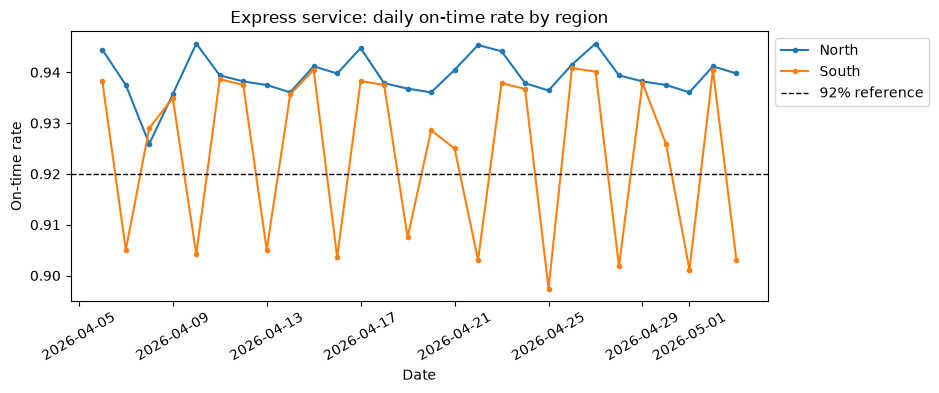

lines drawn: 3 | expected: 3


In [26]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for region in daily_express.columns:
    ax.plot(daily_express.index, daily_express[region], marker="o", markersize=3, label=region)
ax.axhline(0.92, color="black", linestyle="--", linewidth=1, label="92% reference")
ax.set(xlabel="Date", ylabel="On-time rate", title="Express service: daily on-time rate by region")
ax.tick_params(axis="x", labelrotation=30)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

print("lines drawn:", len(ax.lines), "| expected: 3")

**Answer to the manager.** North's express service stayed above 92% on every day; South's fell below 92% on 10 of the 28 days.

### 2.12 Another way: two count tables, then one division

Instead of dividing in the long table and reshaping at the end, we can reshape the **counts** first: one dates × regions table of parcels and one of on-time parcels, using `pivot_table(..., aggfunc="sum")`. Dividing the two tables divides matching cells, because pandas aligns rows and columns by label.

In [27]:
parcels_wide = express.pivot_table(index="date", columns="region", values="parcels", aggfunc="sum")
on_time_wide = express.pivot_table(index="date", columns="region", values="on_time_parcels", aggfunc="sum")
daily_express_b = on_time_wide / parcels_wide

assert np.allclose(daily_express_b.to_numpy(), daily_express.to_numpy())
print("Both ways give the same daily table.")
parcels_wide.head(3)

Both ways give the same daily table.


region,North,South
date,,
2026-04-06,180,162
2026-04-07,176,158
2026-04-08,81,155


This route shows the numerator and denominator of every daily rate side by side. The region/service summary of Step 5 still needs its own `groupby`. Both routes are valid.

### 2.13 From small tasks back to the full question

```
raw            224 x 6    parcels read as text                  Step 1
repaired       224 x 6    parcels numeric, 6 NaN                Step 2
analysis       218 rows   rows with a recorded count            Step 2
with_region    218 rows   + region                              Step 3
with_region    218 rows   + on_time_parcels                     Step 4
summary          4 rows   summed counts per region/service      Step 5
summary          4 rows   + on_time_rate                        Step 6
express        109 rows   express only                          Step 7a
express_daily   56 rows   one row per date and region           Step 7b
daily_express  28 x 2     dates x regions                       Step 7c
checks, days_below_92                                           Step 8
figure                                                          Step 9
```

Each line is one task, one object, one check.

### 3. What to do when you receive a larger coding task

1. **What information do you start from?** List the inputs and say what one position, one row or one key means.
2. **What must you produce?** List every output and its form: a number, a list in a given order, a dictionary keyed by …, a table with one row per …, a figure.
3. **Work backwards.** For each output, ask what must exist just before it.
4. **Plan your tasks.** Write the steps with Input / Task / Output / Check. One step should create one new object.
5. **Which Python tool can do that task?** Use the table below.
6. **Code one task at a time.** Run it, check it, and only then write the next task.
7. **If something fails**, the checks of the earlier steps tell you where to look.

A step is probably too large if you cannot name its output, cannot say how to check it, or its cell is longer than about 15 lines.

| When the task says… | Consider… |
|---|---|
| check that something is true | `assert` |
| same length / no duplicates | `len()`, `set()` |
| go through several aligned lists together | `zip()` + `for` |
| decide one case using rules in order | a function with `if / elif / else` and `return` |
| a total or a count for each key (Python objects) | a dictionary updated in a `for` loop |
| keep the items that satisfy a condition, in order | a list comprehension with `if` |
| keep a copy that must not change | `.copy()` |
| a text column that should be numeric | `pd.to_numeric(..., errors="coerce")` or `na_values=` |
| keep the rows that satisfy a condition | `.loc[condition]`, `.isin()` |
| add information from a lookup table | `merge(..., validate=...)` |
| a total for each group | `groupby(...).agg(...)` or `.sum()` |
| one row per X and one column per Y | `pivot` / `pivot_table` |
| compare series over time | `fig, ax = plt.subplots()`, `ax.plot`, `ax.axhline` |

## Part II — Your turn

You will now work on three new exercises.

Each exercise should take about **30-35'**, and all of them can be solve with Python tools introduced in Sessions 1 and 2.

The amount of guidance will gradually decrease from one exercise to the next.

| | What guidance do you receive? |
|---|---|
| Exercise 1 | You are given the goal, **the Python tool to use**, the object to create, and a check. |
| Exercise 2 | For the first tasks, you are told which Python tool to use. In the later tasks, you are told what object you need to create, but you choose the tool yourself. |
| Exercise 3 | You first write your own plan. For each task, you are told what object to create and how to check it, but you choose the Python tools yourself. |

The objective is not to solve the whole exercise at once.

In each exercise, you will move gradually from:

**one operation → a few connected operations → a short final result**

Work through the tasks in order. After each task, run the corresponding check cell before continuing.

If a check fails, start by looking at the code for the task immediately above it. The earlier checks have already helped you verify the previous parts of the solution.

### Exercise 1 — Processing account transactions in order

**Context**

A payment app receives ten transaction instructions for three prepaid accounts.

The instructions must be processed **in the order in which they were received**, because each accepted instruction changes the account balance that the next instruction will see.

For each instruction, apply the following rules in order:

1. If the amount is zero or negative, reject the instruction.
2. If the transaction kind is neither `"deposit"` nor `"withdrawal"`, reject the instruction.
3. If the instruction is a withdrawal and the amount is greater than the account's **current balance**, reject it.
4. Otherwise, accept the instruction:
   - a deposit increases the balance;
   - a withdrawal decreases the balance.

If an instruction is rejected, the account balance does not change.

**Final objective**

By the end of the exercise, your program should produce:

- one record for each instruction, kept in the original order;
- for each instruction, its status and the account balance immediately after it has been processed;
- the final balance of each account;
- the instructions that were rejected;
- a check showing that each final balance can be reconstructed from the accepted transactions;
- the account with the largest final balance.

The important feature of this exercise is that the instructions are **sequential**.

A withdrawal cannot be assessed using only the starting balance. It must use the balance that exists **at that point in the sequence**, after all earlier accepted instructions for that account have been processed.

In [28]:
opening_balances = {"Nadia": 120.0, "Omar": 40.0, "Iris": 0.0}

tx_ids = ["T01", "T02", "T03", "T04", "T05", "T06", "T07", "T08", "T09", "T10"]
tx_accounts = ["Nadia", "Omar", "Iris", "Omar", "Omar",
               "Nadia", "Iris", "Iris", "Nadia", "Nadia"]
tx_kinds = ["withdrawal", "withdrawal", "deposit", "deposit", "withdrawal",
            "deposit", "transfer", "withdrawal", "withdrawal", "deposit"]
tx_amounts = [50.0, 60.0, 80.0, 30.0, 60.0,
              -20.0, 25.0, 80.0, 75.0, 15.0]

**Instructor solution — reading the question.**

**What do we start from?**

- Four lists describing ten instructions: `tx_ids`, `tx_accounts`, `tx_kinds`, `tx_amounts`. As with the expense claims, the entries in the same position belong to the same instruction: position `0` is T01, a withdrawal of 50.0 from Nadia's account.
- One dictionary, `opening_balances`, with the balance of each of the three accounts before the first instruction.

**What must we produce?**

| Output | What it contains | Level |
|---|---|---|
| `tx_results` | one dictionary per instruction, in the order received, with its status and the balance immediately after it | one result per **instruction** |
| `balances` | the final balance of each account | one result per **account** |
| `rejected_by_account` | the number of rejected instructions of each account | one result per **account** |
| `rejected_ids` | the IDs of the rejected instructions, in the order received | one final list |
| `recomputed` | each final balance, rebuilt from the accepted instructions only | one result per **account** |
| `richest_account` | the account with the largest final balance | one final answer |

**What is new compared with the exercise on the expence claims?**

In Part I, the decision about one claim used only the information of that claim. C105 would have been rejected whatever happened to C101–C104.

Here, rule 3 compares a withdrawal with the account's **current** balance, and the current balance is the result of every earlier accepted instruction on that account. The same instruction can therefore receive a different decision depending on what came before it:

- T02: Omar withdraws 60.0 when his balance is 40.0 --> rejected;
- T04: Omar deposits 30.0, so his balance becomes 70.0;
- T05: Omar withdraws 60.0 again --> this time it is accepted.

If we judged every withdrawal against the *opening* balance instead, three of the ten decisions would change: T05 and T08 would be rejected, and T09 would be accepted.

So the current balance is information that **changes after every accepted instruction**, and the instructions must be processed **in the order received**, each one seeing the balances left by the previous ones.

This already suggests the structure of the program:

1. decide what happens to **one** instruction, given a balance;
2. go through the instructions in order: decide each one, update the balance of its account immediately, and record what happened;
3. after the loop, use the records to summarise the rejections, rebuild the final balances and answer the question.

**My proposed meta-algorithm.**

---

**Step 1 — Verify the inputs** (Task 1.1)\
**Input:** the four lists and `opening_balances`.\
**What do we do?** Check that the lists can be read together, position by position, and that every account has a starting balance.\
**Output:** nothing new.\
**We check:** equal lengths; unique IDs; every name in `tx_accounts` is a key of `opening_balances`.

---

**Step 2 — Decide one instruction** (Task 1.2)\
**Input:** one balance, one kind, one amount.\
**What do we do?** Apply rules 1–4 in order.\
**Output:** `apply_transaction`, returning `(status, new_balance)`.\
**We check:** five cases worked out by hand: one for each rule, and a withdrawal exactly equal to the balance.

The function receives the balance as a **number**. It does not need to know which account the balance belongs to, or where balances are stored: it only decides.

---

**Step 3 — Connect the data to the function** (Task 1.3)\
**Input:** T01, T02 and `opening_balances`.\
**What do we do?** Take one instruction from the lists, look up the balance of its account, call the function.\
**We check:** Python's answers equal our hand answers.

---

**Step 4 — Process all instructions in order** (Task 1.4)\
**Input:** the four lists, `apply_transaction`, a copy of `opening_balances`.\
**What do we do?** For each instruction, in order: read the account's current balance, decide, write the new balance back, store one record.\
**Output:** `balances` (account → current balance) and `tx_results` (one dictionary per instruction).\
**We check:** ten records in the input order; six keys each; no negative balance; `opening_balances` unchanged.

This is the only step where the order of the instructions matters, because it is the only step that changes balances.

---

**Step 5 — Summarise the rejections** (Task 1.5)\
**Input:** `tx_results`.\
**What do we do?** Count the rejected instructions of each account; list the rejected IDs.\
**Output:** `rejected_by_account`, `rejected_ids`.\
**We check:** the counts add up to the length of the list; the IDs follow the input order.

---

**Step 6 — Reconcile and answer** (Task 1.6)\
**Input:** `opening_balances`, `tx_results`, `balances`.\
**What do we do?** Rebuild every final balance from the accepted records only; find the largest final balance.\
**Output:** `recomputed`, `richest_account`.\
**We check:** `recomputed` equals `balances`.

---

Compared with Part I, section 1.10: here the balances **must** be updated inside the loop (Route A), because the next decision depends on them. The rejection summary and the reconciliation change no balance, so they are built afterwards from the completed records (Route B).

#### Task 1.1 — Verify the inputs

Before processing any transaction, check that the input data are consistent.

**Goal:** make sure the four lists can be used together safely.

**Use:** `assert`, `len()`, `set()`, and then a `for` loop with `in`.

**Create:** nothing new.

Check the following three conditions:

1. the four lists have the same length;
2. every transaction ID is unique;
3. every account name appearing in `tx_accounts` is also present in `opening_balances`.

Why do these checks matter?

- If the lists have different lengths, the entries in the same position may no longer describe the same transaction.
- If a transaction ID appears more than once, we can no longer treat it as a unique identifier.
- If an account appears in `tx_accounts` but not in `opening_balances`, we do not know what balance that account should start from.

**Check:** the cell should finish without raising an `AssertionError`.

If an `AssertionError` appears, inspect which of the three assumptions is not satisfied before continuing.

**Solution.** The rest of the exercise reads the four lists position by position: position `0` of each list describes T01, position `1` describes T02, and so on. Before relying on that, we check the three facts listed in the task.

- **Equal lengths.** Otherwise `zip()` would silently stop at the shortest list, and an instruction would be lost or matched with another instruction's amount.
- **Unique IDs.** `rejected_ids` will identify instructions by their ID, so one ID must point to one instruction only. A `set` keeps each ID once, so its length equals the number of instructions only if no ID is repeated.
- **Known accounts.** The loop of Task 1.4 will look up `balances[account]`. A name that is not a key of `opening_balances` has no starting balance, and the loop would stop there with a `KeyError`. A `for` loop over `tx_accounts` with `account in opening_balances` (which checks the keys of the dictionary) tests every name now, with a clear message.

In [29]:
n_tx = len(tx_ids)

assert len(tx_accounts) == n_tx
assert len(tx_kinds) == n_tx
assert len(tx_amounts) == n_tx
assert len(set(tx_ids)) == n_tx

for account in tx_accounts:
    assert account in opening_balances, f"unknown account: {account}"

print("Inputs verified:", n_tx, "instructions,", len(opening_balances), "accounts.")

Inputs verified: 10 instructions, 3 accounts.


The cell finished without an `AssertionError`: the four lists describe the same ten instructions, and each instruction concerns one of the three accounts we know.

The program must decide all ten instructions. But before repeating anything ten times, we first make sure that we can decide **one** instruction correctly.

#### Task 1.2 — Decide one instruction

Now focus on **one transaction only**.

**Goal:** write the four transaction rules once, so that the same logic can later be reused for all ten instructions.

**Use:** a function called:

```python
apply_transaction(balance, kind, amount)
```

Inside the function, use `if / elif / else` to apply the rules in the correct order. The function should **return** a tuple.

**Create:** `apply_transaction`, returning:

```python
(status, new_balance)
```

where:

- `status` is either `"accepted"` or `"rejected"`;
- `new_balance` is the balance after the instruction has been assessed.

If the instruction is rejected, `new_balance` should be equal to the original `balance`.

Before writing the function, think carefully about the order of the rules.

For example, an invalid amount should be rejected *before Python ever considers* whether the instruction is a deposit or a withdrawal.

**Check:** the next cell will test the function on five cases whose answers can be worked out directly from the rules.

| balance | kind | amount | expected result |
|---|---|---|---|
| 100.0 | `deposit` | 20.0 | `("accepted", 120.0)` |
| 30.0 | `withdrawal` | 50.0 | `("rejected", 30.0)` |
| 30.0 | `withdrawal` | 30.0 | `("accepted", 0.0)` |
| 30.0 | `deposit` | −5.0 | `("rejected", 30.0)` |
| 30.0 | `transfer` | 10.0 | `("rejected", 30.0)` |

If one of these checks fails, correct the function before moving on to the full sequence of transactions.

**Solution.** The function receives exactly what the rules need to decide one instruction:

- `balance`: the account's balance **at that moment** (a number, not the account name);
- `kind`: `"deposit"`, `"withdrawal"`, or anything else;
- `amount`.

It does not read or change any dictionary of balances. Deciding an instruction and storing the new balance are kept separate: the function only decides, and Task 1.4 stores the result. This is what allows us to test the function now, on numbers we choose, before any loop exists.

The four rules become four conditions, written in the order of the rules. Python checks them from top to bottom and uses the first one that is true. So:

- an amount of −20.0 is rejected at the first condition, before Python ever looks at the kind;
- `"transfer"` is rejected at the second condition;
- the third condition is reached only by a valid amount with a valid kind, so it only has to ask whether a withdrawal is larger than the balance. It uses `>`, as rule 3 does: a withdrawal **equal** to the balance is accepted and leaves 0.0.

A rejected instruction returns the **same** `balance` it received. So the function always returns a balance, accepted or not, and Task 1.4 can write it back without a special case for rejections.

In [30]:
def apply_transaction(balance, kind, amount):
    """Return (status, new_balance) for one instruction."""
    if amount <= 0:
        return "rejected", balance
    elif kind not in ("deposit", "withdrawal"):
        return "rejected", balance
    elif kind == "withdrawal" and amount > balance:
        return "rejected", balance
    elif kind == "deposit":
        return "accepted", balance + amount
    else:
        return "accepted", balance - amount

In [31]:
# Check for Task 1.2
if apply_transaction(100.0, "deposit", 20.0) is None:
    print("Not attempted yet.")
else:
    assert apply_transaction(100.0, "deposit", 20.0) == ("accepted", 120.0)
    assert apply_transaction(30.0, "withdrawal", 50.0) == ("rejected", 30.0)
    assert apply_transaction(30.0, "withdrawal", 30.0) == ("accepted", 0.0)
    assert apply_transaction(30.0, "deposit", -5.0) == ("rejected", 30.0)
    assert apply_transaction(30.0, "transfer", 10.0) == ("rejected", 30.0)
    print("All five tests passed.")

All five tests passed.


The five tests cover every rule: an accepted deposit, a withdrawal that is too large, a withdrawal exactly equal to the balance (the boundary of rule 3), a negative amount and an unknown kind. If rule 3 had been written with `>=`, the third test would fail here, instead of T08 being silently rejected later in the loop.

We can now decide one instruction from three values typed by hand. The next question is how to obtain those three values **from the data**: which positions of the lists, and which balance.

#### Task 1.3 — Try the first two instructions

Before writing a loop, connect the transaction data to the function you created in Task 1.2.

**Goal:** make sure you know how to take one instruction from the input lists, find the correct current balance, and pass the information to `apply_transaction()`.

**Use:** list indexing, such as:

```python
tx_accounts[0]
tx_kinds[0]
tx_amounts[0]
```

together with:

```python
opening_balances[...]
```

to obtain the starting balance of the relevant account.

**Create:** no new data yet.

For now, simply apply the function to the first two instructions and print the results.

Before running the code, write your expected answers for `T01` and `T02` as comments. Then run the function and compare Python's output with your hand calculation. 

If they do not, stop here and decide whether the problem comes from:

- the way you selected the transaction information;
- the balance you passed to the function;
- or the logic inside `apply_transaction()`.

**Solution.** T01 is position `0` of each list: `tx_accounts[0]` is `"Nadia"`, `tx_kinds[0]` is `"withdrawal"` and `tx_amounts[0]` is `50.0`. The balance is found by using the account name as a key: `opening_balances[tx_accounts[0]]` is Nadia's balance.

For T01 and T02, the opening balance **is** the current balance, because no earlier instruction has touched Nadia's or Omar's account. We write the expected answers as comments first, so that the printed result is compared with something.

In [32]:
# T01: Nadia has 120.0 and withdraws 50.0 -> expected ("accepted", 70.0)
# T02: Omar has 40.0 and withdraws 60.0  -> expected ("rejected", 40.0)
print("T01:", apply_transaction(opening_balances[tx_accounts[0]], tx_kinds[0], tx_amounts[0]))
print("T02:", apply_transaction(opening_balances[tx_accounts[1]], tx_kinds[1], tx_amounts[1]))

T01: ('accepted', 70.0)
T02: ('rejected', 40.0)


Both answers match the hand calculation: Nadia can withdraw 50.0 from 120.0 and is left with 70.0; Omar cannot withdraw 60.0 from 40.0, so his balance stays at 40.0.

Using `opening_balances` was correct for these two instructions, and it would be wrong from now on. T05 is again Omar withdrawing 60.0, but by then T04 has added 30.0 to his account: the balance T05 must see is 70.0, not 40.0. So the program needs an object that holds **each account's current balance** and is updated after every instruction. That is the next task.

**Before running the next cells, think about this:** which object should hold the current balances, and at what exact moment must it be updated?

#### Task 1.4 — Process all instructions in order

We are now ready to process the full sequence of transactions.

The important point is that each accepted instruction changes the balance that the next instruction for that account will see.

**Goal:** apply the transaction rules to all ten instructions, in order, while carrying each account's updated balance from one instruction to the next.

**Use:**

1. Start by creating:

```python
balances = opening_balances.copy()
```

We use `.copy()` because `balances` will change as the transactions are processed. Why? (Task 1.6).

2. Use `zip()` with a `for` loop to move through:

```python
tx_ids
tx_accounts
tx_kinds
tx_amounts
```

together. At each iteration, these four values describe one complete transaction.

3. Inside the loop:

   - read the account's **current** balance from `balances`;
   - call `apply_transaction()` using that balance, the transaction kind and the amount;
   - receive the `status` and `new_balance`;
   - update that account's value in `balances` with `new_balance`.

4. After assessing the instruction, create one dictionary describing what happened and append it to `tx_results`.

**Create:**

- `balances`, containing the current balance of each account as the transactions are processed;
- `tx_results`, containing one dictionary for each of the ten instructions, in their original order.

Each dictionary in `tx_results` should contain:

```python
{
    "tx_id": ...,
    "account": ...,
    "kind": ...,
    "amount": ...,
    "status": ...,
    "balance_after": ...
}
```

The key idea is that `balances` changes during the loop, while `opening_balances` does not: i) if an instruction is accepted, the corresponding balance changes; ii) if an instruction is rejected, `apply_transaction()` returns the same balance, so the account balance remains unchanged.

**Check:** run the next cell to verify that the ten instructions were processed correctly and in the correct order.

**Solution.** We need two objects, with two different jobs.

**1. `balances`: one current balance per account**

Each instruction names an account, and the decision needs that account's balance now. A dictionary keyed by account matches this exactly: the account name in the instruction is the key, and the value is the balance at this point in the sequence. The same key is used to read the balance and to replace it:

```python
balances["Omar"]          # read Omar's current balance
balances["Omar"] = 70.0   # replace it after an accepted deposit
```

We start from `opening_balances.copy()`. Without `.copy()`, `balances = opening_balances` would only give a second name to the **same** dictionary, and every update would also overwrite the opening balances, which Task 1.6 needs.

**2. `tx_results`: one record per instruction**

`balances` only ever holds the latest value. After T05, nothing in `balances` tells us that Omar had 70.0 just before, or that T02 was rejected. The record of each instruction keeps that information. One element of `tx_results` will look like:

```python
{"tx_id": "T05", "account": "Omar", "kind": "withdrawal",
 "amount": 60.0, "status": "accepted", "balance_after": 10.0}
```

As in Part I, the list keeps the instructions in the order received, and each dictionary gives a name to each piece of information.

**Why a `for` loop, and why update immediately?**

A `for` loop over `zip(tx_ids, tx_accounts, tx_kinds, tx_amounts)` handles one instruction per iteration, from T01 to T10, in the order received. Within one iteration we:

1. read `balances[account]`, the balance left by all earlier instructions on this account;
2. call `apply_transaction` with that balance;
3. write `new_balance` into `balances[account]` **before the iteration ends**, so that the next instruction on the same account sees it;
4. append the record.

If step 3 were postponed until after the loop, every instruction would be judged against the opening balances, and T05, T08 and T09 would receive the wrong decision. For a rejected instruction, `new_balance` equals the old balance, so writing it back leaves the account unchanged, as the rules require.

In [33]:
balances = opening_balances.copy()
tx_results = []

for tx_id, account, kind, amount in zip(tx_ids, tx_accounts, tx_kinds, tx_amounts):
    # decide with the account's CURRENT balance, then store the new balance at once,
    # so that the next instruction on the same account sees it
    status, new_balance = apply_transaction(balances[account], kind, amount)
    balances[account] = new_balance
    tx_results.append({
        "tx_id": tx_id,
        "account": account,
        "kind": kind,
        "amount": amount,
        "status": status,
        "balance_after": new_balance,
    })

balances

{'Nadia': 85.0, 'Omar': 10.0, 'Iris': 0.0}

In [34]:
# Check for Task 1.4
if balances is None or tx_results is None:
    print("Not attempted yet.")
else:
    assert [record["tx_id"] for record in tx_results] == tx_ids      # one record per ID, same order
    for record in tx_results:
        assert set(record) == {"tx_id", "account", "kind", "amount", "status", "balance_after"}
        assert record["status"] in ("accepted", "rejected")
        assert record["balance_after"] >= 0
    assert balances is not opening_balances                          # a copy, not the same dictionary
    assert opening_balances == {"Nadia": 120.0, "Omar": 40.0, "Iris": 0.0}
    print("Task 1.4 checks passed.")

Task 1.4 checks passed.


In [35]:
for record in tx_results:
    print(record["tx_id"], record["account"], record["kind"], record["amount"],
          record["status"], record["balance_after"])

T01 Nadia withdrawal 50.0 accepted 70.0
T02 Omar withdrawal 60.0 rejected 40.0
T03 Iris deposit 80.0 accepted 80.0
T04 Omar deposit 30.0 accepted 70.0
T05 Omar withdrawal 60.0 accepted 10.0
T06 Nadia deposit -20.0 rejected 70.0
T07 Iris transfer 25.0 rejected 80.0
T08 Iris withdrawal 80.0 accepted 0.0
T09 Nadia withdrawal 75.0 rejected 70.0
T10 Nadia deposit 15.0 accepted 85.0


The checks confirm that the loop produced one record per instruction, in the order of `tx_ids`, with the six expected keys; that no balance ever became negative, so no withdrawal larger than the balance got through; and that `opening_balances` still holds the original values, so `.copy()` did its job.

The printed records show the sequence at work:

- Omar: 40.0 → T02 rejected (still 40.0) → T04 deposit (70.0) → T05 accepted (10.0);
- Iris: 0.0 → T03 deposit (80.0) → T07 rejected → T08 withdraws exactly 80.0, which is accepted and leaves 0.0;
- Nadia: 120.0 → T01 (70.0) → T06 rejected → T09 asks for 75.0 when only 70.0 is left, so it is rejected even though her opening balance was 120.0 → T10 (85.0).

Each `balance_after` is the history that `balances` alone cannot show.

*Another valid implementation:* `for i in range(len(tx_ids)):` with `tx_ids[i]`, `tx_accounts[i]`, … produces the same records; `zip()` hands us the four values of one instruction directly, without index bookkeeping.

All ten instructions have now been processed, and `balances` holds the final balances. The remaining questions (which instructions were rejected, whether the final balances are right, which account is largest) do not change any balance. They can therefore be answered from the completed records, without processing the instructions again.

#### Task 1.5 — Summarise the rejections

We have now processed all ten instructions and stored the result of each one in `tx_results`. The next task is to summarise the rejected transactions.

**Goal:** count how many rejected instructions each account has, and collect the IDs of all rejected instructions.

**Use:**

- a dictionary and a `for` loop over `tx_results` to build `rejected_by_account`;
- a list comprehension with `if` to build `rejected_ids`.

Start by creating one entry for every account in `opening_balances`, with a rejection count of `0`.

This is important because an account with no rejected instructions should still appear in the final dictionary.

For example, the starting structure should look like:

```python
{
    "Account_A": 0,
    "Account_B": 0,
    "Account_C": 0
}
```

Then loop through `tx_results`.

For each transaction:

1. check whether its `status` is `"rejected"`;
2. if it is, add `1` to the rejection count of the corresponding account.

This gives us:

```python
rejected_by_account
```

which maps each account to its number of rejected instructions.Next, create:

```python
rejected_ids
```

using a list comprehension with an `if` condition. Keep only the transaction IDs whose status is `"rejected"`.

Because `tx_results` is already in input order, the resulting list of IDs will also remain in input order.

**Create:**

- `rejected_by_account`: account → number of rejected instructions;
- `rejected_ids`: the IDs of rejected instructions, in their original order.

**Check:** run the next cell to verify both objects.

**Solution.** Both objects are read from `tx_results`, because each record already says whether the instruction was rejected and which account it concerns.

`rejected_by_account` maps each account to a count, so the account name is again the key. We first give **every** account in `opening_balances` the value 0, and only then go through the records, adding 1 for each rejection. Starting from all accounts, instead of creating a key the first time an account has a rejection, guarantees that an account without rejections still appears, with 0. (In these data every account has at least one rejection, but the program should not depend on that.)

`rejected_ids` keeps only the IDs whose status is `"rejected"`. A list comprehension with `if` goes through `tx_results` in order, so the IDs come out in the order received.

In [36]:
rejected_by_account = {}
for account in opening_balances:
    rejected_by_account[account] = 0
for record in tx_results:
    if record["status"] == "rejected":
        rejected_by_account[record["account"]] += 1

rejected_ids = [record["tx_id"] for record in tx_results if record["status"] == "rejected"]

print(rejected_by_account)
print(rejected_ids)

{'Nadia': 2, 'Omar': 1, 'Iris': 1}
['T02', 'T06', 'T07', 'T09']


In [37]:
# Check for Task 1.5
if rejected_by_account is None or rejected_ids is None:
    print("Not attempted yet.")
else:
    assert set(rejected_by_account) == set(opening_balances)      # every account appears
    assert sum(rejected_by_account.values()) == len(rejected_ids)
    assert rejected_ids == [tx_id for tx_id in tx_ids if tx_id in rejected_ids]   # input order
    print("Task 1.5 checks passed.")

Task 1.5 checks passed.


Four instructions were rejected: two of Nadia's, one of Omar's and one of Iris's. The counts add up to the length of `rejected_ids`, so each rejection was counted once and only once, and the IDs are in input order.

We also have the final balances in `balances`. But they were produced by the loop we want to verify: if that loop had changed a balance it should not have, `balances` would contain the mistake, and the checks so far would not necessarily show it. So before answering the last question, we rebuild the final balances in a different way.

#### Task 1.6 — Reconcile and answer

We have reached the final stage of the exercise.

Before answering the last management question, we first want to check that the final balances are consistent with the transactions we processed.

**Goal:** recompute each final balance in a different way, compare it with `balances`, and then identify the account with the largest final balance.

---

**1. Recompute the final balances**

Create a new dictionary called:

```python
recomputed
```

Start from the original `opening_balances`. Then loop through `tx_results`. For each transaction:

- ignore it if its `status` is `"rejected"`;
- if it is an accepted deposit, add the amount;
- if it is an accepted withdrawal, subtract the amount.

Use only:

```python
opening_balances
tx_results
```

for this calculation. Do **not** use `balances`. Why?

Because the purpose of this step is to check `balances` independently.

If we used `balances` to reconstruct `balances`, the check would tell us very little.

The logic is:

**opening balance + accepted deposits − accepted withdrawals = final balance**

You can reuse the dictionary-and-loop pattern from Task 1.5.

---

**2. Find the account with the largest final balance**

Create:

```python
richest_account
```

using the final values in `balances`:

- loop through the dictionary with `.items()`;
- keep track of the largest balance seen so far;
- keep the account associated with that balance.

**Create:**

- `recomputed`, containing one independently reconstructed final balance per account;
- `richest_account`, the account with the largest final balance.

**Check:** run the next cell to compare `recomputed` with `balances`.

If the two dictionaries agree, the final balances have been obtained in two different ways and give the same result.

**Solution.** The reconstruction uses a relationship that does not depend on the loop:

**final balance = opening balance + accepted deposits − accepted withdrawals**

Each record in `tx_results` contains the account, the kind, the amount and the status, which is all this relationship needs. `recomputed` starts as a copy of `opening_balances` (again, so that the opening balances are not changed). We then go through the records: the amount of every **accepted** deposit is added to its account, and the amount of every **accepted** withdrawal is subtracted from it. Rejected records are skipped.

`recomputed` uses neither `balances` nor the `balance_after` values: those are the numbers we are checking. If we rebuilt `balances` from `balances`, the two would agree whatever the loop had done.

In [38]:
recomputed = opening_balances.copy()
for record in tx_results:
    if record["status"] == "accepted" and record["kind"] == "deposit":
        recomputed[record["account"]] += record["amount"]
    elif record["status"] == "accepted" and record["kind"] == "withdrawal":
        recomputed[record["account"]] -= record["amount"]
print("recomputed:", recomputed)
print("balances:  ", balances)

recomputed: {'Nadia': 85.0, 'Omar': 10.0, 'Iris': 0.0}
balances:   {'Nadia': 85.0, 'Omar': 10.0, 'Iris': 0.0}


The two dictionaries show the same three numbers; the check cell below confirms it with `assert`.

The last question is about the **largest** final balance. The answer is already inside `balances`, so we use the pattern of Part I, section 1.8: go through `balances.items()`, which gives each account together with its balance, and keep the largest balance seen so far and the account it belongs to.

In [39]:
richest_account = None
richest_balance = -1.0                     # every balance is >= 0, so the first account replaces this
for account, balance in balances.items():
    if balance > richest_balance:
        richest_account = account
        richest_balance = balance
print("largest final balance:", richest_account, richest_balance)

largest final balance: Nadia 85.0


In [40]:
# Check for Task 1.6
if recomputed is None or richest_account is None:
    print("Not attempted yet.")
else:
    for account in opening_balances:
        assert abs(recomputed[account] - balances[account]) < 1e-9, f"{account} does not reconcile"
    assert richest_account in opening_balances
    print("Every final balance reconciles.")
    print("Rejected:", rejected_ids, "| largest final balance:", richest_account)

Every final balance reconciles.
Rejected: ['T02', 'T06', 'T07', 'T09'] | largest final balance: Nadia


**Expected results.**

| Account | Opening balance | Final balance | Rejected instructions |
|---|---|---|---|
| Nadia | 120.0 | 85.0 | T06 (negative amount, rule 1); T09 (75.0 > 70.0, rule 3) |
| Omar | 40.0 | 10.0 | T02 (60.0 > 40.0, rule 3) |
| Iris | 0.0 | 0.0 | T07 (unknown kind `"transfer"`, rule 2) |

`rejected_ids` is `['T02', 'T06', 'T07', 'T09']`, and the account with the largest final balance is Nadia (85.0).

**What the reconciliation proves, and what it does not.** `recomputed` agrees with `balances`, so the loop changed each balance by exactly the accepted instructions and by nothing else. A loop that subtracted the amount of a rejected withdrawal, or forgot to write the new balance back, would not pass. The reconciliation does **not** re-check the rules themselves, because it takes the statuses from `tx_results`: that was the job of the five tests in Task 1.2. T08 (a withdrawal exactly equal to the balance) is the instruction in the data where writing `>=` in rule 3 would change the result, and the third test of Task 1.2 is the one that catches it.

The whole exercise, as a chain of objects:

**four lists + `opening_balances` → `apply_transaction` (one instruction) → `balances` and `tx_results` (the loop, in order) → `rejected_by_account`, `rejected_ids` → `recomputed`, `richest_account`**

Only the loop changes the balances. Everything after it reads the completed records.

### Exercise 2 — Valuing a small portfolio from daily prices

**Context**

An investment club holds shares in four stocks. The file:

```python
data/session4_portfolio_prices.csv
```

contains the daily prices of those stocks over 20 trading days. Each row contains:

- `date`;
- `ticker`;
- `close`.

The number of shares held in each stock is given in the `holdings` table below. For two observations, the closing price was not received. In those rows, the file contains:

```python
no_quote
```

instead of a price. For each stock on each date:

```text
position value = closing price × number of shares held
```

The total value of the portfolio on a date is therefore:

```text
portfolio value = sum of the four position values on that date
```

There is one important rule: if the price of **even one stock** is missing on a particular date, we cannot calculate the value of the complete portfolio on that date.

We must therefore remove that date **for all four stocks**, not only remove the row containing `no_quote`.

**Final objective**

By the end of the exercise, your analysis should produce:

- the total portfolio value for every date on which all four prices are available;
- the number of complete dates on which the portfolio value is below its value on the first complete date;
- the contribution of each stock to the change in portfolio value between the first and the last complete date;
- one figure showing how the portfolio value changes over time.

The important idea in this exercise is that a problem in **one row** can affect whether an **entire date** can be used.

In [41]:
holdings = pd.DataFrame({
    "ticker": ["NOVA", "LUMA", "PINE", "ORCA"],
    "shares": [40, 120, 60, 25],
})
holdings

,ticker,shares
0,NOVA,40
1,LUMA,120
2,PINE,60
3,ORCA,25


**Read the data and the question.**

**What do we start from?**

- The CSV file. One row is **one stock on one date**: the date, the ticker and the closing price. Four stocks over 20 trading days give 80 rows. Two prices were not received and appear as `no_quote`.
- `holdings`, with **one row per stock**: the ticker and the number of shares the club holds. There is one number per stock, used on every date.

**What do the finance terms mean here?**

- The **position value** of a stock on a date is what the club's shares of that stock are worth at that day's closing price: `position value = close × shares`. For example, 120 LUMA shares at 18.00 are worth 2,160.00.
- The **portfolio value** on a date is the value of everything the club holds that day: the sum of the four position values.

Nothing else from finance is needed.

**What must we produce?** One portfolio value for every complete date; the number of dates on which it is below its value on the first date; each stock's contribution to the change between the first and the last date; one figure.

**Work backwards from the outputs.**

1. The figure, the count of dates below the start and the overall change all need **one portfolio value per date**.
2. The portfolio value of a date needs **the four position values of that date**, and all four must exist.
3. A position value needs, on the same row, a **numeric price** and the **number of shares**.
4. "All four must exist" means that a date with one missing price cannot be valued at all: it must be removed for **every** stock, not only for the stock whose price is missing.
5. To find the missing prices, and to compute with all the others, the `close` column must first be converted from text to numbers, with `no_quote` represented as missing.

The contributions need something more: each stock's position value on the first and on the last date. Both final questions become simple once the position values are arranged with **one row per date and one column per stock**: a portfolio value is then the sum across one row, and a contribution is the difference between the last and the first row of one column.

Read from 5 back to 1, this gives the sequence of objects the solution builds:

**`raw_prices` (prices as text) → `prices` (numeric, 2 missing) → `complete` (complete dates only) → `valued` (+ shares, + position values) → `wide` (dates × tickers) → `portfolio_value` (one value per date) → `days_below`, `contributions`, figure**

**Instructor plan (meta-algorithm).**

| Step | Input | What do we do? | Output | We check |
|---|---|---|---|---|
| 1 (Task 2.1) | the CSV file | load it and look at it | `raw_prices` | 80 × 3; `close` is read as text |
| 2 (Task 2.2) | `raw_prices` | convert `close` to numbers; `no_quote` becomes `NaN` | `prices` | number of `NaN` = number of `no_quote` |
| 3 (Task 2.3) | `prices` | find the dates with a missing price; remove every row on those dates | `bad_dates`, `complete` | no `NaN` left; exactly 4 rows per date |
| 4 (Task 2.4) | `complete`, `holdings` | attach the shares; multiply them by the price | `valued` | same rows as `complete`; no missing shares |
| 5 (Task 2.5) | `valued` | arrange the position values as dates × tickers; sort the dates | `wide` | one row per date, 4 columns, no `NaN`, first row = first date |
| 6 (Task 2.6) | `wide`, and separately `valued` | add the four positions of each date, in two ways | `portfolio_value`, `portfolio_value_check` | the two agree |
| 7 (Task 2.7) | `portfolio_value`, `wide` | compare with the first date; last row − first row | `days_below`, `contributions` | contributions add up to the portfolio change |
| 8 (Task 2.8) | `portfolio_value` | draw the daily value and the starting level; write the answer | figure | two lines |

WATCH OUT for Step 3: `dropna()` alone removes the two rows with `no_quote` but keeps 10 and 19 March with only three stocks. On those two dates the "portfolio" would then be worth roughly 2,000 less than on the neighbouring dates, as if the club had lost about a quarter of its value overnight. The "4 rows per date" check catches this.

#### Task 2.1 — Load and inspect the price data

Before calculating any portfolio values, first look at the dataset as pandas has read it.

**Goal:** understand the shape of the table, the type of each column, and whether anything needs to be repaired before we can calculate with the prices.

**Use:**

```python
pd.read_csv(PRICES_PATH, parse_dates=["date"])
```

Then inspect the result using:

```python
.shape
.dtypes
.head()
```

**Create:** `raw_prices`.

Remember what we expect from the data:

- 4 stocks;
- 20 trading days;
- one row for each date–ticker combination.

So the complete file should contain:

```text
4 × 20 = 80 rows
```

and 3 columns:

```text
date, ticker, close
```

**Check:** confirm that `raw_prices` has 80 rows and 3 columns. Then inspect the column types (one column has been read as text? Which column is it?).

**Solution.** Before computing anything with the prices, we look at how pandas has read them. We know what to expect: 4 stocks × 20 trading days = 80 rows, and three columns, `date`, `ticker` and `close`. `parse_dates=["date"]` turns the dates into real dates while loading, so that later they can be sorted and compared.

In [42]:
raw_prices = pd.read_csv(PRICES_PATH, parse_dates=["date"])
raw_prices.head()

,date,ticker,close
0,2026-03-02,LUMA,18.00
1,2026-03-03,LUMA,18.03
2,2026-03-04,LUMA,17.74
3,2026-03-05,LUMA,17.95
4,2026-03-06,LUMA,17.73


In [43]:
# Check for Task 2.1
if raw_prices is None:
    print("Not attempted yet.")
else:
    print("shape:", raw_prices.shape, "| expected: (80, 3)")
    print(raw_prices.dtypes)

shape: (80, 3) | expected: (80, 3)
date      datetime64[us]
ticker               str
close                str
dtype: object


80 rows and 3 columns: the file has one row for every date–ticker combination, as expected. The first rows are all LUMA on consecutive dates, so the file lists one stock's days and then moves to the next stock.

`close` has not been read as a numeric dtype, because the column contains the literal marker `no_quote`. A single entry that cannot be read as a number is enough to stop pandas from treating the whole column as numeric, and here there are two such entries. (The dtype name printed above depends on the pandas version: here it is `str`, and older versions show `object`. What matters is that it is not a numeric dtype such as `float64`.) Prices that are not stored as numbers cannot be multiplied by a number of shares, so the next task is to repair the column.

#### Task 2.2 — Repair the prices

The `close` column contains the text `no_quote`. We now need to repair that column before using it in any valuation calculation.

**Goal:** create a numeric `close` column, with every `no_quote` entry represented as a missing value.

**Use:**

Start from a copy of the original table:

```python
prices = raw_prices.copy()
```

Then convert the `close` column with:

```python
pd.to_numeric(..., errors="coerce")
```

The option:

```python
errors="coerce"
```

tells pandas to convert valid prices to numbers and replace anything that cannot be interpreted as a number with `NaN`.

So every `no_quote` entry becomes a missing value.

**Create:** `prices`.

At this stage, keep all 80 rows. We are only repairing the price column; we have not yet decided which dates can be used for portfolio valuation.

**Check:** compare:

- the number of `no_quote` entries in `raw_prices`;
- the number of missing values in `prices["close"]`.

These two numbers should be the same.

If they are not, inspect the conversion before moving to the next task.

**Solution.** `pd.to_numeric(..., errors="coerce")` tells pandas: *convert every entry to a number; if an entry cannot be converted, put `NaN` instead.* A valid price such as `"18.03"` becomes `18.03`, and each `no_quote` becomes a missing value.

We work on `raw_prices.copy()`, so that `raw_prices` still shows the file as it was read; the check below needs it to count the markers. All 80 rows are kept: this task only repairs the column. Which dates can be used is a separate decision, taken in the next task.

In [44]:
prices = raw_prices.copy()
prices["close"] = pd.to_numeric(prices["close"], errors="coerce")
prices.dtypes

date      datetime64[us]
ticker               str
close            float64
dtype: object

In [45]:
# Check for Task 2.2
if prices is None:
    print("Not attempted yet.")
else:
    n_markers = (raw_prices["close"] == "no_quote").sum()
    print("close dtype:", prices["close"].dtype)
    print("missing closes:", prices["close"].isna().sum(), "| no_quote markers:", n_markers)
    assert prices["close"].isna().sum() == n_markers

close dtype: float64
missing closes: 2 | no_quote markers: 2


`close` is now `float64` and contains 2 missing values, as many as there are `no_quote` markers in the file.

Why is that equality evidence? `errors="coerce"` turns **anything** that is not a number into `NaN`, including, for example, a mistyped price such as `"18,03"`. If such an entry existed, there would be more `NaN` than markers, and that price would be lost without any error message. Equal counts mean that the only missing prices are the two that were never received.

We now know which **rows** have no price. The rule in the statement, however, is about **dates**: if one of the four prices of a date is missing, the portfolio cannot be valued on that date.

**Before running the next cells, think about this:** if we simply dropped the two rows with a missing price, what would the portfolio value look like on those two dates?

#### Task 2.3 — Remove the incomplete dates

We now know which individual rows have a missing closing price.

But the rule applies at the **date level**: if even one stock is missing a price on a given date, that entire date cannot be used to value the portfolio.

So this task has two connected parts.

**Goal:** identify the incomplete dates, then remove all rows belonging to those dates.

**Use:**

1. Find the dates where `close` is missing.

Use `.loc[]` together with `.isna()` to select the `date` values from those rows. Store the result in:

```python
bad_dates
```

2. Remove every row whose date appears in `bad_dates`.

Use:

```python
.isin(bad_dates)
```

to identify those rows, and `~` to reverse the condition so that we keep only dates that are **not** in `bad_dates`. Store the result in:

```python
complete
```

**Create:**

- `bad_dates`, containing the dates with at least one missing closing price;
- `complete`, containing only dates for which all four stock prices are available.

Why do we remove the whole date? Because the portfolio value for a date requires the value of all four positions. Keeping the three available stocks and ignoring the missing one would give the value of an incomplete portfolio.

**Check:**

- `complete["close"]` should contain no missing values;
- every remaining date should appear exactly 4 times, once for each stock.

If a remaining date has fewer than 4 rows, then the portfolio for that date is still incomplete.

**Solution.** A missing price does not only remove one position value. It makes the **whole date** unusable, because the portfolio value of that date needs all four positions. So we use the rows with a missing price to identify dates, and then remove those dates for all four stocks. This takes two operations.

**1. Which dates?** `prices["close"].isna()` is `True` on the rows with a missing price. Inside `.loc[]` it selects those rows, and the second argument, `"date"`, keeps only their dates. The result is `bad_dates`.

In [46]:
bad_dates = prices.loc[prices["close"].isna(), "date"]
print("dates removed:", bad_dates.tolist())

dates removed: [Timestamp('2026-03-10 00:00:00'), Timestamp('2026-03-19 00:00:00')]


There are two incomplete dates: 10 March, when LUMA has no price, and 19 March, when ORCA has none. On each of these dates the other three prices are fine, and they must be removed anyway.

**2. Remove every row on those dates.** `prices["date"].isin(bad_dates)` is `True` for each of the 8 rows (2 dates × 4 stocks) whose date is in `bad_dates`. `~` reverses it, so `.loc[~...]` keeps the rows whose date is **not** in `bad_dates`. `.copy()` makes `complete` a table of its own rather than a view of part of `prices`.

In [47]:
complete = prices.loc[~prices["date"].isin(bad_dates)].copy()

In [48]:
# Check for Task 2.3
if complete is None:
    print("Not attempted yet.")
else:
    rows_per_date = complete.groupby("date").size()
    assert complete["close"].notna().all(), "a missing close is still there"
    assert (rows_per_date == 4).all(), "some dates do not have all four stocks"
    print("complete dates:", complete["date"].nunique(), "| rows:", len(complete))

complete dates: 18 | rows: 72


18 complete dates and 72 rows: 80 − 2 dates × 4 stocks = 72, and 72 / 4 = 18.

The two checks prove different things. "No missing close" would also pass after a plain `dropna()`. "Exactly 4 rows per date" is the check that proves every remaining date has the prices of **all four** stocks, which is what the valuation needs.

We now have usable prices on complete dates. But a price is not yet a value: to know what the club's holding in a stock is worth, we also need the number of shares, which is in a different table, `holdings`.

#### Task 2.4 — Value each position

We now have only complete dates, but each row still contains only the stock price.

To calculate the value of each position, we also need to know how many shares of that stock the investment club holds.

**Goal:** attach the number of shares to every price observation, then calculate the value of each position.

**Use:**

Merge `complete` with the `holdings` table using:

```python
on="ticker"
how="left"
validate="many_to_one"
```

This is the same type of merge we used in Part I:

- many price observations can belong to the same ticker;
- each ticker should appear only once in `holdings`, with one number of shares.

After the merge, calculate:

```python
position_value = close * shares
```

using column arithmetic.

**Create:** `valued`, containing two new columns:

- `shares`;
- `position_value`.

Each row now tells us not only the stock price, but also the value of the club's position in that stock on that date.

**Check:**

- `valued` should have the same number of rows as `complete`;
- `shares` should contain no missing values.

If `shares` contains a missing value, then at least one ticker in the price data did not find a match in the `holdings` table.

**Solution.** We have two tables with different rows:

- `complete`: one row per **stock and date**, with the price;
- `holdings`: one row per **stock**, with the number of shares.

The column they share is `ticker`. We want to add, to every row of `complete`, the number of shares of its ticker. This is the same situation as attaching the region to each delivery in Part I, so we use the same `merge`:

- `how="left"`, because `complete` is the table we want to keep, row by row;
- `validate="many_to_one"`, because **many** price rows belong to the same ticker (18 each), while each ticker must appear **once** in `holdings`, with one number of shares. If a ticker appeared twice in `holdings`, pandas would raise an error instead of silently duplicating price rows.

In [49]:
valued = complete.merge(holdings, on="ticker", how="left", validate="many_to_one")
valued.head(3)

,date,ticker,close,shares
0,2026-03-02,LUMA,18.00,120
1,2026-03-03,LUMA,18.03,120
2,2026-03-04,LUMA,17.74,120


Each row now has the price **and** the number of shares on the same line: the first row reads LUMA, 18.00, 120 shares. The position value is their product, row by row. As with `on_time_parcels` in Part I, this is one column multiplied by another, so no loop is needed.

In [50]:
valued["position_value"] = valued["close"] * valued["shares"]   # value of the club's shares of this stock on this date
valued.head()

,date,ticker,close,shares,position_value
0,2026-03-02,LUMA,18.00,120,2160.0
1,2026-03-03,LUMA,18.03,120,2163.6
2,2026-03-04,LUMA,17.74,120,2128.8
3,2026-03-05,LUMA,17.95,120,2154.0
4,2026-03-06,LUMA,17.73,120,2127.6


In [51]:
# Check for Task 2.4
if valued is None:
    print("Not attempted yet.")
else:
    assert len(valued) == len(complete)
    assert valued["shares"].notna().all()
    assert "position_value" in valued.columns
    print("Task 2.4 checks passed.")

Task 2.4 checks passed.


`valued` has the same 72 rows as `complete`, so the merge neither lost nor duplicated a price observation; and no `shares` value is missing, so every ticker found its row in `holdings`.

We now have the position values, but in **long** form: one row per stock and date. The two final questions need them organised differently:

- the portfolio value of a date is the sum of **four different rows** of `valued`;
- a stock's contribution compares its row on the first date with its row on the last date.

Both become simple when each date is one row and each stock is one column. That is the next task.

#### Task 2.5 — One row per date, one column per stock

We now have one row for each stock on each complete date, together with its `position_value`.

The next step is to reorganise these values into a table that is easier to use for portfolio calculations.

**Goal:** create a table with:

- one row for each date;
- one column for each ticker;
- the corresponding `position_value` in each cell.

You built this kind of table in Part I. Decide which pandas tool is appropriate here.

**Create:** `wide`.

The structure should look conceptually like this:

```text
ticker       Stock A    Stock B    Stock C    Stock D
date
date 1         ...        ...        ...        ...
date 2         ...        ...        ...        ...
date 3         ...        ...        ...        ...
```

**Check:**

- `wide` has one row for every date in `complete`;
- `wide` has 4 columns, one for each stock;
- there are no missing values;
- the first row corresponds to the earliest date.

**Solution.** We want a table in which:

- one **row** is one complete date;
- one **column** is one ticker;
- one **cell** is the value of the club's position in that ticker on that date.

This has the shape of `daily_express` in Part I (dates in the rows, regions in the columns), so the tool is the same: `pivot_table` with `date` as the index, the `ticker` values as the columns and `position_value` in the cells.

Each date–ticker pair appears exactly once in `valued`, so `aggfunc="sum"` adds a single number and leaves it unchanged; it only states what should happen if a pair ever appeared twice.

The rows of `wide` are indexed by date, and Task 2.7 will use the first and the last row by position (`.iloc[0]` and `.iloc[-1]`). Rather than rely on the order in which the reshape happens to return the dates, we sort the rows chronologically ourselves with `wide.sort_index()`. After that, `.iloc[0]` is the earliest complete date and `.iloc[-1]` the latest.

In [52]:
wide = valued.pivot_table(index="date", columns="ticker", values="position_value", aggfunc="sum")
wide = wide.sort_index()          # chronological order: .iloc[0] = earliest date, .iloc[-1] = latest
wide.head()

ticker,LUMA,NOVA,ORCA,PINE
date,,,,
2026-03-02,2160.0,2000.0,2250.00,2100.0
2026-03-03,2163.6,2016.8,2272.75,2123.4
2026-03-04,2128.8,2034.0,2268.50,2136.0
2026-03-05,2154.0,2057.6,2230.50,2128.8
2026-03-06,2127.6,2036.4,2266.50,2169.0


In [53]:
# Check for Task 2.5
if wide is None:
    print("Not attempted yet.")
else:
    assert wide.shape == (complete["date"].nunique(), 4)
    assert not wide.isna().any().any()
    assert wide.index[0] == complete["date"].min()
    print("wide:", wide.shape)

wide: (18, 4)


`wide` has 18 rows and 4 columns: every complete date and every ticker. Its first row is the earliest complete date, as the sort guarantees. No cell is missing, which confirms once more that each of the 18 dates has all four positions. Had we used `dropna()` alone in Task 2.3, the rows for 10 and 19 March would appear here, each with one empty cell.

*Another valid implementation:* `valued.pivot(index="date", columns="ticker", values="position_value")` gives the same table, because each date–ticker pair appears once. `pivot` would raise an error if a pair appeared twice, which is itself a check.

Each row of `wide` now holds the four position values of one date side by side. The portfolio value of that date is, by definition, their sum.

#### Task 2.6 — Daily portfolio value, computed two ways

We now have the value of each individual position on every complete date.

The next step is to combine the four positions into one total portfolio value for each date.

**Goal:** calculate one portfolio value per date, and calculate it in two different ways.

**Create:**

- `portfolio_value`: start from `wide` and add the four position values across each row;
- `portfolio_value_check`: start again from `valued` and obtain one total per date using a different pandas operation.

The two objects should represent exactly the same quantity:

```text
portfolio value on a date = sum of the four position values on that date
```

Why calculate it twice? Because the second calculation gives us an independent check of the first one. 

**Check:**

- both objects contain one value for each complete date;
- the dates correspond;
- the values agree, using `np.allclose()`.

If the two calculations disagree, do not continue.

**Solution.** The task asks for the same quantity computed in two different ways, so that the second calculation checks the first.

**From `wide`.** The four position values of a date are the four cells of one row, so the portfolio value of a date is the sum of its row. `wide.sum(axis=1)` does this: `axis=1` collapses the column axis, leaving one value for each row, that is, one portfolio value for each date. The result is indexed by date.

In [54]:
portfolio_value = wide.sum(axis=1)          # axis=1 collapses the column axis: one value per date
portfolio_value.head()

date
2026-03-02    8510.00
2026-03-03    8576.55
2026-03-04    8567.30
2026-03-05    8570.90
2026-03-06    8599.50
dtype: float64

On the first date: 2,160.00 + 2,000.00 + 2,250.00 + 2,100.00 = 8,510.00, the first value above.

**From `valued`.** In the long table, the four rows of one date belong to the same portfolio value. Grouping the rows by `date` collects them, and summing `position_value` inside each group gives one total per date. This route does not use `wide` at all.

In [55]:
portfolio_value_check = valued.groupby("date")["position_value"].sum()
portfolio_value_check.head()

date
2026-03-02    8510.00
2026-03-03    8576.55
2026-03-04    8567.30
2026-03-05    8570.90
2026-03-06    8599.50
Name: position_value, dtype: float64

In [56]:
# Check for Task 2.6
if portfolio_value is None or portfolio_value_check is None:
    print("Not attempted yet.")
else:
    assert len(portfolio_value) == len(wide)
    assert np.allclose(np.asarray(portfolio_value), np.asarray(portfolio_value_check))
    print("Both calculations agree.")

Both calculations agree.


The two calculations agree on all 18 dates. Since the second one never went through `wide`, the agreement shows that the reshaping of Task 2.5 neither lost nor duplicated a position value. If they disagreed, the problem would be in Tasks 2.3–2.5, and the checks of those tasks would tell us where.

*Other valid ways:* `wide.to_numpy().sum(axis=1)` (a NumPy array instead of a Series, so the dates are no longer attached to the values), or `valued.pivot_table(index="date", values="position_value", aggfunc="sum")`.

We now have one portfolio value per complete date. The remaining questions compare these values over time: with the value on the **first** date, and between the first and the **last** date.

#### Task 2.7 — Days below the starting value and each stock's contribution

We now have the daily portfolio value and the position value of each stock on every complete date.

**Goal:** calculate:

- how often the portfolio falls below its value on the first complete date;
- how much each stock contributes to the change in portfolio value between the first and the last complete date.

**Create:**

- `days_below`: the number of dates on which `portfolio_value` is smaller than its value on the **first** date;
- `contributions`: one value per ticker, calculated as:

```text
position value on the last date − position value on the first date
```

The contribution is therefore positive if that stock's position value increased between the first and last date, and negative if it decreased.

**Check:** the four stock contributions should add up to the total change in portfolio value between the first and the last complete date.

In other words:

```text
sum of stock contributions
=
portfolio value on last date − portfolio value on first date
```

**Solution.** The task contains two separate questions, so we answer them one at a time.

**Days below the start.** `start_value = portfolio_value.iloc[0]` is the value on the first date: `portfolio_value` was computed row by row from the date-sorted `wide`, so it keeps the same chronological order, and position `0` is the earliest complete date. `portfolio_value < start_value` compares every date with it and gives one `True` or `False` per date. Summing a Boolean Series counts its `True` values, so `.sum()` gives the number of dates below the start. The first date is never counted, because it is not below its own value.

In [57]:
start_value = portfolio_value.iloc[0]
days_below = (portfolio_value < start_value).sum()
print("first value:", start_value, "| last value:", round(portfolio_value.iloc[-1], 2))
print("dates below the first value:", days_below)

first value: 8510.0 | last value: 8443.55
dates below the first value: 8


The portfolio started at 8,510.00, ended at 8,443.55, and was below its starting value on 8 of the 18 dates.

**Contributions.** The portfolio lost 66.45 between the first and the last date. Which stocks account for this? Because `wide` is sorted by date, its first row (`wide.iloc[0]`) holds the four position values on the earliest complete date and its last row (`wide.iloc[-1]`) the four values on the latest. `wide.iloc[-1] - wide.iloc[0]` subtracts one row from the other; pandas matches the two rows by ticker, so each stock's last value is compared with its own first value.

In [58]:
contributions = wide.iloc[-1] - wide.iloc[0]
contributions.sort_values()

ticker
LUMA   -279.60
ORCA    -32.25
PINE     51.00
NOVA    194.40
dtype: float64

In [59]:
# Check for Task 2.7
if days_below is None or contributions is None:
    print("Not attempted yet.")
else:
    daily_values = portfolio_value.tolist()
    change = daily_values[-1] - daily_values[0]
    assert len(contributions) == 4
    assert np.isclose(contributions.sum(), change)
    print("Contributions add up to the portfolio change.")

Contributions add up to the portfolio change.


Why must the contributions add up to the change in the portfolio? Each portfolio value is the sum of the four positions in its row, so

(sum of the last row) − (sum of the first row) = sum, over the four stocks, of (last value − first value).

The check therefore confirms that `wide` and `portfolio_value` describe the same positions on the same first and last dates. Here: −279.60 (LUMA) − 32.25 (ORCA) + 51.00 (PINE) + 194.40 (NOVA) = −66.45.

All the numbers are now available. The last task presents them.

#### Task 2.8 — Figure and final answer

The last step is to present the result visually and briefly interpret it.

**Goal:** compare the daily portfolio value with its value on the first complete date.

**Create:**

one figure containing:

- the daily `portfolio_value` as a line;
- a dashed horizontal reference line at the portfolio value on the first date;
- a label for the horizontal axis;
- a label for the vertical axis;
- a title;
- a legend.

Your answer should use the results you have already calculated, including:

- `days_below`;
- the stock contributions to the change from the first to the last date.

**Check:** the figure should contain two lines:

1. the daily portfolio value;
2. the horizontal line showing the starting value.

**Solution.** The question is how the portfolio value moves over time **compared with where it started**. One line shows `portfolio_value` against its dates; a dashed horizontal line at `portfolio_value.iloc[0]` marks the starting value. The 8 dates counted in `days_below` are exactly the points that lie under the dashed line.

lines drawn: 2 | expected: 2


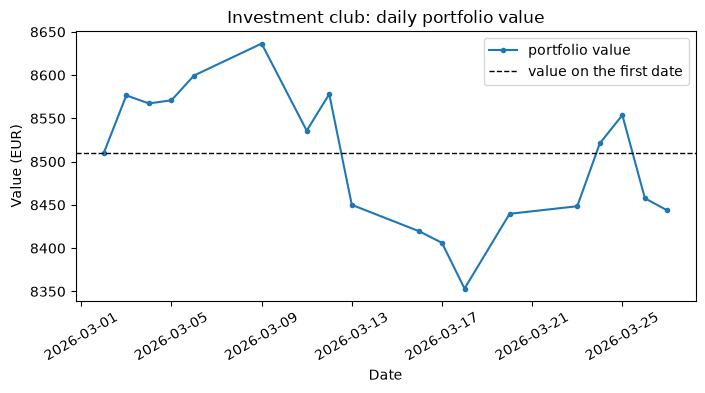

In [60]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(portfolio_value.index, portfolio_value, marker="o", markersize=3, label="portfolio value")
ax.axhline(portfolio_value.iloc[0], color="black", linestyle="--", linewidth=1,
           label="value on the first date")
ax.set(xlabel="Date", ylabel="Value (EUR)", title="Investment club: daily portfolio value")
ax.tick_params(axis="x", labelrotation=30)
ax.legend()

print("lines drawn:", len(ax.lines), "| expected: 2")
plt.show()

**Answer.** On the 18 complete dates, the portfolio started at EUR 8,510.00 and ended at EUR 8,443.55, a fall of EUR 66.45. It was below its starting value on 8 dates. NOVA added the most (+194.40) and LUMA lost the most (−279.60); PINE contributed +51.00 and ORCA −32.25. The LUMA loss alone is larger than the fall of the whole portfolio.

**From small tasks back to the full question.**

```text
raw_prices        80 x 3    one row per date and ticker; close read as text    Task 2.1
prices            80 x 3    close numeric; the 2 no_quote become NaN           Task 2.2
bad_dates         2         10 and 19 March                                    Task 2.3
complete          72 rows   complete dates only: 18 dates x 4 tickers          Task 2.3
valued            72 rows   + shares, + position_value                         Task 2.4
wide              18 x 4    dates in rows, tickers in columns                  Task 2.5
portfolio_value   18        one value per date; equals portfolio_value_check   Task 2.6
days_below        8         dates below the value on the first date            Task 2.7
contributions     4         last minus first position value, per ticker        Task 2.7
figure                      daily value and the starting level                 Task 2.8
```

Each object is built from the one above it by one operation, and each was checked before the next task used it.

*Instructor note:* two dates (10 and 19 March) were removed. Students who used `dropna()` only, and went past the failing check of Task 2.3, will see two sharp dips on those dates in the figure (to about 6,600 and 6,200), because three positions are presented as the whole portfolio. This is a useful discussion point.

### Exercise 3 — Choosing the cheapest mobile plan

**Context**

A company pays the mobile plans of six employees.

There are three available plans. Each plan has:

- a monthly `fee`;
- an amount of data included in the fee, `included_gb`;
- an additional cost per GB above that allowance, `extra_per_gb`.

For one month:

```text
monthly cost
=
fee + extra_per_gb × GB used above the allowance
```

If usage stays within the included allowance, the extra charge is zero.

The table `usage` gives each employee's data use in January, February and March.

The dictionary `current_plan` gives the plan currently assigned to each employee.

**Final objective**

For each employee, find:

- the plan that would have been cheapest over the three months;
- the saving compared with the employee's current plan.

Then produce:

- the list of employees who should switch;
- the company's total potential saving;
- a bar chart showing the saving for each employee.

In [61]:
plans = {
    "Basic": {"fee": 8.0, "included_gb": 5, "extra_per_gb": 2.0},
    "Plus": {"fee": 15.0, "included_gb": 15, "extra_per_gb": 1.5},
    "Max": {"fee": 25.0, "included_gb": 40, "extra_per_gb": 1.0},
}

usage = pd.DataFrame({
    "employee": ["Ana", "Ben", "Chen", "Dara", "Eli", "Femi"] * 3,
    "month": ["Jan"] * 6 + ["Feb"] * 6 + ["Mar"] * 6,
    "gb": [3, 12, 30, 6, 16, 22,
           4, 18, 45, 9, 14, 25,
           2, 10, 38, 7, 20, 19],
})

current_plan = {"Ana": "Basic", "Ben": "Max", "Chen": "Plus",
                "Dara": "Plus", "Eli": "Plus", "Femi": "Plus"}
usage.head(7)

,employee,month,gb
0,Ana,Jan,3
1,Ben,Jan,12
2,Chen,Jan,30
3,Dara,Jan,6
4,Eli,Jan,16
5,Femi,Jan,22
6,Ana,Feb,4


#### Task 3.0 — Plan your tasks

**My proposed meta-algorithm.**

**What do we start from?**

- `usage`: one row per **employee and month**, with the GB used. Six employees × three months = 18 rows.
- `plans`: a dictionary from plan name to its pricing rule. Each rule is itself a small dictionary with `fee`, `included_gb` and `extra_per_gb`.
- `current_plan`: a dictionary from employee to the name of the plan they have today.

**What must we produce?** For each employee, the cheapest plan over the three months and the saving compared with the current plan; then the employees who should switch, the total saving and a bar chart.

**Work backwards from the outputs.**

1. A saving is (three-month cost of the current plan) − (three-month cost of the cheapest plan).
2. The cheapest plan of an employee can only be found by comparing that employee's three-month cost under **each** of the three plans. So we need all 6 × 3 employee–plan costs.
3. A three-month cost is the sum of three monthly costs.
4. A monthly cost is the pricing rule of one plan applied to one month's GB.

Read from 4 back to 1, the open question becomes a concrete sequence:

**pricing rule for one plan and one month → cost of every month under every plan → three-month cost of every employee under every plan → comparison across the plans of each employee → cheapest plan → saving against the current plan → switchers, total, chart**

**The plan, step by step.**

**Step 1 — One month, one plan** (Task 3.1)\
Input: one plan dictionary and one GB value. Task: apply the formula, with no extra charge when usage is within the allowance. Output: `monthly_cost(plan, gb)`. Check: cases computed by hand, including usage exactly at the allowance.\
Tool: a function with `if / else` and `return`. The same rule is used 54 times (18 employee-months × 3 plans), so it is written once.

**Step 2 — Every month under every plan** (Task 3.2)\
Input: `usage`, `plans`, `monthly_cost`. Task: one cost column per plan. Output: the columns `Basic`, `Plus`, `Max` in `usage`. Check: still 18 rows; no missing cost; no cost below the plan's fee.\
Tool: a `for` loop over `plans.items()`, which gives each plan's name (the column label) and its rule (the function's argument), with a list comprehension over `usage["gb"]`.

**Step 3 — Three-month cost per employee and plan** (Task 3.3)\
Input: `usage`. Task: add the three months of each employee, separately for each plan. Output: `totals`, one row per employee and one column per plan. Check: 6 × 3; the grand total is unchanged.\
Tool: `groupby("employee")` on the three plan columns, then `.sum()`.

**Step 4 — Cheapest plan per employee** (Task 3.4)\
Input: `totals`. Task: in each row, find the smallest cost and the plan it belongs to. Output: `report` with `best_plan` and `best_cost`. Check: the best cost is the cost of the best plan and is not larger than any other plan's cost.\
Tool: the "best so far" loop of Part I, section 1.8, with "smallest" in place of "largest", applied to each row.

**Step 5 — Compare with the current plan** (Task 3.5)\
Input: `report`, `totals`, `current_plan`. Task: attach the current plan, look up its three-month cost, subtract. Output: the columns `current_plan`, `current_cost`, `savings`. Check: no negative saving; a saving is zero exactly when the current plan costs as much as the cheapest plan.\
Tool: `pd.Series(current_plan)`, which lines up with `report` by employee name; `.loc[employee, plan]` to read one cell of `totals`.

**Step 6 — Final result** (Task 3.6)\
Input: `report`. Task: select the employees with a positive saving, add the savings, draw them. Output: `switchers`, `total_savings`, a bar chart.\
Tool: a list comprehension with `if`, `.sum()`, `ax.bar`.

Good student plans may merge Steps 2 and 3 (compute each employee's three-month cost directly in a loop) or build the employee–plan costs as a dictionary of dictionaries. Any plan whose intermediate objects can be checked is acceptable. What matters is that the comparison of Step 4 is made between **three-month** costs.

#### Task 3.1 — One month, one plan

**Task:** write the cost rule for one month.

**Create:** a function:

```python
monthly_cost(plan, gb)
```

where `plan` is one of the plan dictionaries, for example:

```python
plans["Basic"]
```

The function should return:

```text
monthly fee + any extra data charge
```

If usage is within the included allowance, the extra charge is zero.

**Check:** the next cell should confirm:

- Basic, 4 GB → `8.0`
- Basic, 8 GB → `14.0`
- Plus, 15 GB → `15.0`
- Max, 41 GB → `26.0`

**Solution.** The smallest piece of the problem is one plan and one month. Everything else repeats this calculation, so we write it once, as a function.

The formula contains one condition: there is an extra charge **only if** usage is above the allowance.

- `extra_gb = gb - plan["included_gb"]` is the usage above the allowance. It is negative when usage is below the allowance.
- If `extra_gb > 0`, the cost is the fee plus `extra_gb × extra_per_gb`.
- Otherwise, the cost is the fee alone. Without this `else`, a light user would receive a negative extra charge: Ana's 3 GB in January would cost 8 − 2 × 2 = 4.0 on Basic instead of 8.0.

`plan` is one of the inner dictionaries, so the function reads its three numbers by name: `plan["fee"]`, `plan["included_gb"]`, `plan["extra_per_gb"]`. It does not need to know the plan's name.

In [62]:
def monthly_cost(plan, gb):
    """Cost of one month under one plan (a dictionary with fee, included_gb, extra_per_gb)."""
    extra_gb = gb - plan["included_gb"]
    if extra_gb > 0:
        return plan["fee"] + extra_gb * plan["extra_per_gb"]
    else:
        return plan["fee"]

In [63]:
# Check for Task 3.1
if monthly_cost(plans["Basic"], 4) is None:
    print("Not attempted yet.")
else:
    assert monthly_cost(plans["Basic"], 4) == 8.0
    assert monthly_cost(plans["Basic"], 8) == 14.0
    assert monthly_cost(plans["Plus"], 15) == 15.0
    assert monthly_cost(plans["Max"], 41) == 26.0
    print("All four tests passed.")

All four tests passed.


The four tests cover the cases the formula distinguishes: usage within the allowance (Basic, 4 GB → the fee only, 8.0), usage above it (Basic, 8 GB → 8 + 3 × 2 = 14.0), usage **exactly** at the allowance (Plus, 15 GB → no extra GB, so 15.0) and one GB above it (Max, 41 GB → 25 + 1 × 1 = 26.0).

We can now price one month under one plan. The question compares plans over three months for six employees, so the next task applies the rule to **every** month in `usage`, under **every** plan.

#### Task 3.2 — Every month under every plan

**Task:** calculate what each employee-month would cost under each of the three plans.

Add three new columns to `usage`:

```python
"Basic"
"Plus"
"Max"
```

Each column should contain the monthly cost under that plan.

**Create:** three new cost columns in `usage`.

**Check:**

- the three plan columns exist;
- `usage` still has 18 rows;
- no cost is missing;
- no monthly cost is below that plan's monthly fee.

**Solution.** `usage` has one row per employee-month. On each row we want three more numbers: the cost of that month under Basic, under Plus and under Max. Three plans give three new columns, each named after its plan.

- A `for` loop over `plans.items()` visits the three plans. At each step it gives the plan's **name**, which becomes the column label, and its **rule**, which is passed to `monthly_cost`.
- For one plan, `[monthly_cost(plan, gb) for gb in usage["gb"]]` applies the rule to the 18 GB values in the order of the rows. The list has 18 costs, the first belonging to the first row, so assigning it to `usage[name]` places each cost on its own row.

In [64]:
for name, plan in plans.items():
    usage[name] = [monthly_cost(plan, gb) for gb in usage["gb"]]
usage.head(6)

,employee,month,gb,Basic,Plus,Max
0,Ana,Jan,3,8.0,15.0,25.0
1,Ben,Jan,12,22.0,15.0,25.0
2,Chen,Jan,30,58.0,37.5,25.0
3,Dara,Jan,6,10.0,15.0,25.0
4,Eli,Jan,16,30.0,16.5,25.0
5,Femi,Jan,22,42.0,25.5,25.0


In [65]:
# Check for Task 3.2
missing_columns = [name for name in plans if name not in usage.columns]
if missing_columns:
    print("Not attempted yet. Missing columns:", missing_columns)
else:
    assert len(usage) == 18
    for name, plan in plans.items():
        assert usage[name].notna().all()
        assert (usage[name] >= plan["fee"]).all(), f"a {name} cost is below its fee"
    print("Task 3.2 checks passed.")

Task 3.2 checks passed.


Each of the 18 rows now carries its GB and the cost of that month under each plan. For example, Chen used 30 GB in January: 58.0 on Basic, 37.5 on Plus, 25.0 on Max.

The checks say that no row was lost (still 18), that every cost was computed (no `NaN`), and that no cost is below the plan's fee. The last one confirms that the "fee only" branch of the function works on every row of the data, not only on the four tests.

*Another valid implementation:* one vectorised expression per plan, for example `np.where(usage["gb"] > plan["included_gb"], plan["fee"] + (usage["gb"] - plan["included_gb"]) * plan["extra_per_gb"], plan["fee"])`. It avoids calling the function 18 times, but writes the formula a second time; the function keeps the rule in one place.

The question, however, is about the cost over **three months**, not month by month. So the next task adds the months together.

#### Task 3.3 — Three-month total per employee

**Task:** add together January, February and March for each employee, separately for each plan.

**Create:** `totals`, a table with:

- one row per employee;
- one column for each plan.

Each cell should contain that employee's total three-month cost under that plan.

**Check:**

- `totals` has 6 rows;
- `totals` has 3 columns;
- the sum of all values in `totals` equals the sum of the three plan-cost columns in `usage`.

**Solution.** Rows with the same employee belong to the same three-month total. `groupby("employee")` collects the three rows of each employee; selecting the plan columns and applying `.sum()` adds the three months **separately in each plan column**. `plan_names` is the list of the three column names, taken from `plans` so that the code does not repeat them.

The result, `totals`, is the employee-by-plan cost table:

- one **row** per employee;
- one **column** per plan;
- one **cell** = what that employee would have paid over the three months on that plan.

This representation is chosen with the next two tasks in mind. The three alternatives of one employee sit **side by side in one row**, so finding the cheapest plan becomes a comparison within a row. And any employee–plan cost, including the cost of the current plan, is one cell that `.loc[employee, plan]` can read.

In [66]:
plan_names = list(plans.keys())
totals = usage.groupby("employee")[plan_names].sum()
totals

,Basic,Plus,Max
employee,,,
Ana,24.0,45.0,75.0
Ben,74.0,49.5,75.0
Chen,220.0,147.0,80.0
Dara,38.0,45.0,75.0
Eli,94.0,54.0,75.0
Femi,126.0,76.5,75.0


In [67]:
# Check for Task 3.3
if totals is None:
    print("Not attempted yet.")
else:
    assert totals.shape == (usage["employee"].nunique(), len(plans))
    assert set(totals.columns) == set(plans)
    assert np.isclose(totals.to_numpy().sum(), usage[list(plans.keys())].to_numpy().sum())
    print("Task 3.3 checks passed.")

Task 3.3 checks passed.


`totals` has 6 rows and 3 columns, and the sum of all its cells equals the sum of the three cost columns of `usage`: every monthly cost was added once, none twice and none lost.

*Another valid implementation:* `usage.pivot_table(index="employee", values=plan_names, aggfunc="sum")` builds the same table.

We now have every employee–plan cost. The problem has become a **comparison**: in each row of `totals`, which of the three numbers is the smallest, and to which plan does it belong?

**Before running the next cells, think about this:** how would you find the cheapest plan of one employee by hand, from their row of `totals`? Which loop from Part I does the same thing?

#### Task 3.4 — The cheapest plan for each employee

**Task:** for each employee, find the plan with the lowest three-month cost and the value of that cost.

**Create:** `report`, a table with:

- one row per employee, with employee names as the index;
- a `best_plan` column;
- a `best_cost` column.

**Check:**

- `best_cost` equals the cost of `best_plan` for that employee in `totals`;
- `best_cost` is not greater than the cost of any of the three plans for that employee.

**Solution.** Start with **one** employee. Femi's row of `totals` reads: Basic 126.0, Plus 76.5, Max 75.0. Reading it by hand, Max is the cheapest, at 75.0.

To make Python read a row in the same way, we use the "best so far" pattern of Part I, section 1.8, with **smallest** in place of largest: go through the plans of the row one at a time, and keep the plan whose cost is the smallest seen so far. `totals.loc["Femi"]` is one row; like a dictionary, its `.items()` gives each plan name together with its cost.

We write this as a function, `cheapest_plan(row)`, for the same reason as `assess_claim` in Part I and `apply_transaction` in Exercise 1: decide one case, check it, then repeat it.

In [68]:
def cheapest_plan(row):
    """Return (plan, cost) for the smallest cost in one row of totals."""
    best_plan = None
    best_cost = None
    for plan_name, cost in row.items():
        if best_cost is None or cost < best_cost:     # the first plan, or a cheaper one
            best_plan = plan_name
            best_cost = cost
    return best_plan, best_cost

femi_plan, femi_cost = cheapest_plan(totals.loc["Femi"])
print("Femi:", femi_plan, femi_cost)

Femi: Max 75.0


The function agrees with the reading by hand. Now we repeat the same decision for every employee: a `for` loop over `totals.index` passes each employee's row to `cheapest_plan` and collects the two answers in two lists. The lists then become the two columns of `report`, with the employee names as index, so that `report` has one row per employee, like `totals`.

In [69]:
best_plans = []
best_costs = []
for employee in totals.index:
    plan_name, cost = cheapest_plan(totals.loc[employee])
    best_plans.append(plan_name)
    best_costs.append(cost)

report = pd.DataFrame({"best_plan": best_plans, "best_cost": best_costs}, index=totals.index)
report

,best_plan,best_cost
employee,,
Ana,Basic,24.0
Ben,Plus,49.5
Chen,Max,80.0
Dara,Basic,38.0
Eli,Plus,54.0
Femi,Max,75.0


In [70]:
# Check for Task 3.4
if report is None:
    print("Not attempted yet.")
else:
    for employee in totals.index:
        best_plan = report.loc[employee, "best_plan"]
        assert best_plan in plans
        assert report.loc[employee, "best_cost"] == totals.loc[employee, best_plan]
        assert report.loc[employee, "best_cost"] <= totals.loc[employee].min()
    print("Task 3.4 checks passed.")

Task 3.4 checks passed.


The check confirms, for every employee, that `best_cost` is the cost of `best_plan` in `totals` and that no other plan is cheaper.

Once the comparison is understood, pandas also provides a shorter way to write it. `totals.min(axis=1)` gives the smallest value of each row, and `totals.idxmin(axis=1)` gives the **column label** of that smallest value, which here is the plan name (it works like `idxmax`, seen in Session 2). Together they do what `cheapest_plan` does row by row, and give the same answer:

In [71]:
best_plan_pandas = totals.idxmin(axis=1)     # for each row, the column label of the smallest value
best_cost_pandas = totals.min(axis=1)

assert (best_plan_pandas == report["best_plan"]).all()
assert np.allclose(best_cost_pandas, report["best_cost"])
print("idxmin / min give the same cheapest plans.")

idxmin / min give the same cheapest plans.


Both versions are correct. The loop shows the comparison step by step with Session-1 tools; `idxmin` is a convenience once we know what the comparison must do. Nothing in the exercise requires knowing it by name.

`report` now says which plan would have been cheapest for each employee. The question, however, is how much the company would **save**, and that depends on what each employee pays today.

#### Task 3.5 — Compare with the current plan

**Task:** compare the cheapest plan with the plan each employee currently has.

For each employee, add to `report`:

- the current plan;
- the three-month cost of that current plan;
- the saving from switching to the cheapest plan.

Calculate:

```text
saving = current cost − best cost
```

**Create:** three new columns in `report`:

- `current_plan`;
- `current_cost`;
- `savings`.

**Check:**

- no value in `savings` is negative;
- `savings` is `0` exactly when `best_plan` is the same as `current_plan`.

**Solution.** Three columns are added to `report`, one after the other.

**`current_plan`.** `current_plan` is a dictionary from employee to plan name. `pd.Series(current_plan)` turns it into a Series whose index is the employee names. When this Series is assigned as a column of `report`, pandas places each value on the row **with the same label**, not in the same position: Ben's current plan goes on Ben's row, whatever the order of the dictionary.

**`current_cost`.** The three-month cost of the current plan is already in `totals`: it is the cell in the employee's row and the current plan's column. A list comprehension over the pairs (employee, current plan) reads each of those cells with `totals.loc[employee, plan]`. This is where the employee-by-plan table is useful: the current cost is a lookup, not a new calculation.

**`savings`.** `current_cost − best_cost`: one column minus another.

In [72]:
report["current_plan"] = pd.Series(current_plan)          # aligned on the employee names
report["current_cost"] = [totals.loc[employee, plan]
                          for employee, plan in zip(report.index, report["current_plan"])]
report["savings"] = report["current_cost"] - report["best_cost"]
report

,best_plan,best_cost,current_plan,current_cost,savings
employee,,,,,
Ana,Basic,24.0,Basic,24.0,0.0
Ben,Plus,49.5,Max,75.0,25.5
Chen,Max,80.0,Plus,147.0,67.0
Dara,Basic,38.0,Plus,45.0,7.0
Eli,Plus,54.0,Plus,54.0,0.0
Femi,Max,75.0,Plus,76.5,1.5


In [73]:
# Check for Task 3.5
if report is None or "savings" not in report.columns:
    print("Not attempted yet.")
else:
    assert report["current_plan"].notna().all()
    assert (report["savings"] >= 0).all()
    zero_saving = np.isclose(report["savings"], 0)
    same_cost = np.isclose(report["current_cost"], report["best_cost"])
    assert (zero_saving == same_cost).all()      # zero saving <=> current plan costs the minimum
    print("Task 3.5 checks passed.")

Task 3.5 checks passed.


The checks say two things:

- no saving is negative. Since `best_cost` is the smallest cost of the row, the current plan can never be cheaper; a negative saving would mean that the "cheapest" plan of Task 3.4 was not the cheapest;
- a saving is zero **exactly** when the current plan costs as much as the cheapest plan, that is, when `current_cost` equals `best_cost` (compared with `np.isclose`, because these are decimal amounts). A zero saving means that the employee's current plan already costs the minimum available amount.

The check compares **costs**, not plan names. In principle, two plans could tie at the minimum cost. `best_plan` would then name only one of them (the first one found), and an employee on the other plan would have a zero saving even though `best_plan` differs from `current_plan`. Before saying anything about plan names, we check whether any employee has such a tie:

In [74]:
tied = [employee for employee in totals.index
        if np.isclose(totals.loc[employee], report.loc[employee, "best_cost"]).sum() > 1]
print("employees with two or more plans at the minimum cost:", tied)

employees with two or more plans at the minimum cost: []


No employee has a tie at the minimum, so in this dataset a zero saving also means that `best_plan` **is** the current plan: Ana (Basic) and Eli (Plus) are already on their cheapest plan, and every other employee would pay strictly less after switching. (The **Check** of Task 3.5 is phrased with plan names; without ties, the two formulations agree, as they do here.)

`report` now holds everything the final answer needs, one row per employee. What remains is to select, add up and show.

#### Task 3.6 — Final result

**Task:** use `report` to answer the management question.

**Create:**

- `switchers`: the list of employees whose `savings` are positive, keeping the same order as `report`;
- `total_savings`: the total three-month saving if all employees with a positive saving switch plans;
- a bar chart showing the saving for each employee, with axis labels and a title;
- one or two sentences in the Markdown cell below the chart summarising the result.

**Check:** the next cell should confirm that:

- `switchers` contains exactly the employees in `report` whose `savings` are positive;
- `total_savings` equals the sum of the `savings` column in `report`.

**Solution.**

- `switchers`: a list comprehension over `report.index` that keeps the employees whose `savings` is positive. Going through `report.index` keeps the order of `report`.
- `total_savings`: `report["savings"].sum()`. The employees who should not switch have a saving of exactly 0 (checked in Task 3.5), so adding the whole column gives the same total as adding the switchers only.
- The chart compares one number across six employees, so it is a bar chart with one bar per employee. There is no time axis here, so a line would suggest a sequence that does not exist.

In [75]:
switchers = [employee for employee in report.index if report.loc[employee, "savings"] > 0]
total_savings = report["savings"].sum()
print("should switch:", switchers)
print("total saving over three months: EUR", total_savings)

should switch: ['Ben', 'Chen', 'Dara', 'Femi']
total saving over three months: EUR 101.0


In [76]:
# Check for Task 3.6
if switchers is None or total_savings is None:
    print("Not attempted yet.")
else:
    assert len(switchers) == (report["savings"] > 0).sum()
    assert np.isclose(total_savings, report.loc[switchers, "savings"].sum())
    print("Task 3.6 checks passed.")

Task 3.6 checks passed.


bars drawn: 6 | expected: 6


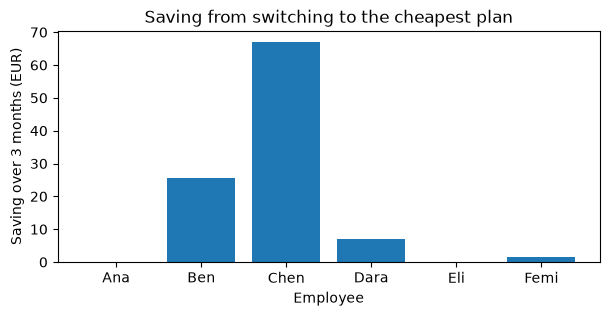

In [77]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(report.index, report["savings"])
ax.set(xlabel="Employee", ylabel="Saving over 3 months (EUR)",
       title="Saving from switching to the cheapest plan")

print("bars drawn:", len(ax.patches), "| expected: 6")
plt.show()

**Answer.** Four employees should switch: Ben (Max → Plus, saving 25.5), Chen (Plus → Max, 67.0), Dara (Plus → Basic, 7.0) and Femi (Plus → Max, 1.5). Ana and Eli are already on their cheapest plan. Over the three months the company would have saved EUR 101.0, two thirds of it from Chen alone.

*Instructor note:* Femi is a deliberately close case (75.0 on Max vs 76.5 on Plus). Students who compare **monthly** costs instead of three-month totals may reach a different choice for Dara and Femi: Dara is cheaper on Plus in February (15.0 vs 16.0 on Basic) and Femi on Plus in March (21.0 vs 25.0 on Max), although over the three months Basic and Max are cheaper for them. The checks in Tasks 3.4 and 3.5 are structural and would not catch this, so ask students which quantity they compared.

#### From the plan to the code

Task 3.0 asked for a plan before any code. Here is how each step of that plan became an operation, and which object each operation produced.

| Step of the plan | What it means in this problem | Operation | Object produced |
|---|---|---|---|
| employee usage | GB used by each employee in each month | given | `usage`: 18 × 3, one row per employee-month |
| pricing rule for one plan | fee, plus `extra_per_gb` for each GB above `included_gb` | a function with `if / else` | `monthly_cost` (Task 3.1) |
| cost of one employee under one plan | the rule applied to each month, then the months added; e.g. Femi on Plus: 25.5 + 30.0 + 21.0 = 76.5 | `monthly_cost` on each month, then a sum | one cell of `totals` |
| costs for every employee–plan combination | all 6 × 3 three-month costs, side by side | a `for` loop over `plans.items()` with a list comprehension (Task 3.2); `groupby("employee")[...].sum()` (Task 3.3) | `usage` + 3 cost columns; `totals`: 6 × 3, the employee-by-plan table |
| comparison across plans → cheapest plan | the smallest cost in each row, and its plan | "best so far" loop over each row (`cheapest_plan`); `min` / `idxmin` as a shortcut | `report`: `best_plan`, `best_cost` (Task 3.4) |
| saving against today | current cost read from `totals`, minus the best cost | `pd.Series(current_plan)`, `.loc[employee, plan]`, column subtraction | `report` + `current_plan`, `current_cost`, `savings` (Task 3.5) |
| final communication | who should switch, how much the company saves, shown per employee | list comprehension with `if`, `.sum()`, `ax.bar` | `switchers`, `total_savings`, bar chart (Task 3.6) |

The question was open: *which plan should each employee have?* It became a concrete sequence of operations once we asked, working backwards, what each output needs: a saving needs two three-month costs, a three-month cost needs three monthly costs, and a monthly cost needs one rule applied to one number. Each object in the table was checked before the next one was built from it.